In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
MODE = "light"

In [3]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [4]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import (
    show_single_channel_red_green_black as S,
    to_show_list as tsl,
    show_72,
    show_72_list,
    scatter_plot_1d,
    mk_rect_on_ax,
    get_receptive,
    otsu_threshold,
    explain_variance_with_pca,
)
from tqdm import tqdm
from pt_to_api.contribs.v1 import (
    show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP,
)
import seaborn as sns
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning, DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import (
    pairwise_distances,
    cosine_similarity,
    cosine_distances,
)
from scipy.optimize import linear_sum_assignment
import pandas as pd

from neural_data.utils import (
    get_full_conv_kernel_at_coordinate,
    get_saliency_map_ids_and_patches,
    get_full_activations_of_layer,
)
from collections import defaultdict
import itertools
from torch import nn
from torch import optim


In [5]:
def show_gram(W):
    W_norm = W / (W.norm(dim=0, keepdim=True) + 1e-8)
    gram = W_norm.T @ W_norm  # (n_components, n_components)
    plt.imshow(gram, cmap="gray")
    plt.show()
    return gram

In [6]:
class GroupingAutoencoderFixedSigma(nn.Module):
    def __init__(self, input_dim, n_components):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, n_components, bias=True),
        )
        self.decoder = nn.Linear(n_components, input_dim, bias=False)

    def forward(self, x):
        codes = self.encoder(x)
        recon = self.decoder(codes)
        return recon, codes

    def loss_fn(self, x, recons, codes, alpha, sigma_x, sigma_s, sigma_0):
        recons_loss = self.recon_loss(x, recons, sigma_x)

        codes_loss = self.codes_loss(codes, sigma_s)

        weights_loss = self.weights_loss(alpha, sigma_0)

        return recons_loss, codes_loss, weights_loss

    def codes_loss(self, codes, sigma_s):
        return self.gauss_loss(codes, 0) / (sigma_s*sigma_s)

    def recon_loss(self, x, recons, sigma_x):
        return self.gauss_loss(x, recons) / (sigma_x*sigma_x)

    def cauchy_loss(self, x, cauchy_gamma):
        return torch.log(1 + (x*x) / (cauchy_gamma*cauchy_gamma)).sum()

    def cauchy_codes_loss(self, codes, cauchy_gamma):
        return torch.log(1 + (codes*codes) / (cauchy_gamma*cauchy_gamma)).sum(1).mean()

    def gauss_loss(self, x, mean):
        loss = ((x - mean) ** 2)
        # sum the loss inside one example, send back mean across examples for the batch
        return torch.sum(loss, 1).mean()

    def l1_loss(self, x, mean):
        loss = (x - mean).abs()
        return torch.sum(loss, 1).mean()

    def weights_loss(self, alpha, sigma_0):
        W = self.decoder.weight
        W_sq = W ** 2  # (C, K)
        cumsum = torch.cumsum(W_sq, dim=1)          # (C, K), cumsum[c,k] = sum W[c,0..k]^2
        phi = alpha * torch.roll(cumsum, 1, dims=1) + 1  # (C, K)
        phi[:, 0] = 1  # k=0: phi_weight(W, c, -1, alpha) = alpha*0 + 1
        comp1 = (W_sq * phi) / (sigma_0*sigma_0)
        comp2 = -torch.log(phi)
        # we just send the sum, this is per example loss btw
        # the others are sending mean so all good
        return (comp1 + comp2).sum()

    def weights_loss_cycled(self, alpha, sigma_0, chunk_size=64):
        W = self.decoder.weight          # (C, K)
        C, K = W.shape

        idx = (torch.arange(K, device=W.device).unsqueeze(0) +
            torch.arange(K, device=W.device).unsqueeze(1)) % K   # (K, K)

        shift_losses = []

        for start in range(0, K, chunk_size):
            idx_chunk = idx[start:start + chunk_size]   # (chunk, K)

            W_chunk = W[:, idx_chunk]                   # (C, chunk, K)
            W_chunk = W_chunk.permute(1, 0, 2)          # (chunk, C, K)

            W_sq = W_chunk ** 2

            cumsum = torch.cumsum(W_sq, dim=2)
            phi = alpha * torch.roll(cumsum, 1, dims=2) + 1
            phi[:, :, 0] = 1

            comp1 = (W_sq * phi) / (sigma_0 * sigma_0)
            comp2 = -torch.log(phi)

            shift_losses.append((comp1 + comp2).sum(dim=(1, 2)))  # (chunk,)

        return torch.cat(shift_losses).mean()

    def masked_recon_loss(self, x, recons, sigma_x):
        mask = (x != 0).float()
        loss = ((x - recons) ** 2) * mask
        return torch.sum(loss, 1).mean() / (sigma_x**2)

In [7]:
def make_dim_partition(patch_dim, n_components, seed=42):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(patch_dim)
    return [list(perm[i::n_components]) for i in range(n_components)]

def generate_synthetic_patches(patch_dim=72, n_components=10, k=3, n_samples=1000, noise_std=0.01, seed=42):
    rng = np.random.RandomState(seed)
    
    dim_partition = make_dim_partition(patch_dim, n_components, seed)
    
    # ground truth atoms, nonzero only on owned dims
    W_true = np.zeros((n_components, patch_dim))
    for i, dims in enumerate(dim_partition):
        W_true[i, dims] = rng.randn(len(dims))
    W_true /= np.linalg.norm(W_true, axis=1, keepdims=True)
    
    # each sample uses exactly k atoms
    codes_true = np.zeros((n_samples, n_components))
    for i in range(n_samples):
        idx = rng.choice(n_components, k, replace=False)
        codes_true[i, idx] = rng.randn(k)
    
    X = codes_true @ W_true
    X += rng.randn(*X.shape) * noise_std
    
    return X, W_true, codes_true, dim_partition

def evaluate_recovery(W_learned, W_true, threshold=0.95):
    """
    W_learned: (n_atoms, patch_dim)
    W_true: (n_atoms, patch_dim)
    
    for each true atom, finds the best matching learned atom by cosine similarity
    returns fraction of true atoms recovered above threshold
    """
    W_l = W_learned / (np.linalg.norm(W_learned, axis=1, keepdims=True) + 1e-8)
    W_t = W_true / (np.linalg.norm(W_true, axis=1, keepdims=True) + 1e-8)
    
    sim = np.abs(W_l @ W_t.T)  # (n_atoms, n_atoms), abs because sign is arbitrary
    best_match = sim.max(axis=0)  # for each true atom, best cosine with any learned atom
    
    recovered = (best_match >= threshold).mean()
    print(f"Mean best cosine similarity: {best_match.mean():.4f}")
    print(f"Fraction recovered (>{threshold}): {recovered:.4f}")
    return best_match, recovered


def _match_atoms(D1: np.ndarray, D2: np.ndarray):
    """
    Match atoms of D1 to atoms of D2 using the Hungarian algorithm
    on cosine distances. Assumes square dictionaries (same n_components).

    D1, D2: shape (n_components, n_features) — sklearn's components_ layout.

    Returns:
        row_ind, col_ind: matched index arrays
        matched_similarities: per-pair cosine similarities
        mean_sim: mean cosine similarity across matched pairs
    """
    # Guard against dead atoms (zero-norm rows produce NaN cosine distances)
    norms_1 = np.linalg.norm(D1, axis=1, keepdims=True)
    norms_2 = np.linalg.norm(D2, axis=1, keepdims=True)
    if np.any(norms_1 == 0) or np.any(norms_2 == 0):
        raise ValueError(
            "One or more atoms have zero norm. "
            "Remove or replace dead atoms before matching."
        )

    # cost = cosine_distances(D1, D2)          # shape (n_components, n_components), values in [0, 2]
    cost = np.abs(cosine_similarity(D1, D2))
    cost = 1 - cost

    row_ind, col_ind = linear_sum_assignment(cost)
    matched_similarities = 1 - cost[row_ind, col_ind]
    mean_sim = float(matched_similarities.mean())
    return row_ind, col_ind, matched_similarities, mean_sim


def hungarian_match(all_components: list[np.ndarray]):
    """
    Pairwise similarity matching across runs using the Hungarian algorithm.

    Args:
        all_components: list of arrays, each shape (n_components, n_features).
                        All arrays must have the same shape.

    Returns:
        upper: 1-D array of pairwise similarities for all unique pairs
        stability_score: mean of upper
        best_run_idx: index of the run most similar to all others
        pairwise_sims: (n_runs, n_runs) symmetric similarity matrix, diagonal = 1
    """
    n_runs = len(all_components)

    if n_runs < 2:
        raise ValueError("Need at least 2 runs to compute pairwise similarity.")

    shapes = [d.shape for d in all_components]
    if len(set(shapes)) != 1:
        raise ValueError(
            f"All dictionaries must have the same shape. Got: {shapes}"
        )

    pairwise_sims = np.ones((n_runs, n_runs))
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            _, _, _, mean_sim = _match_atoms(all_components[i], all_components[j])
            pairwise_sims[i, j] = mean_sim
            pairwise_sims[j, i] = mean_sim

    upper = pairwise_sims[np.triu_indices(n_runs, k=1)]
    stability_score = float(upper.mean())

    # Exclude self-similarity (diagonal=1) when ranking runs
    np.fill_diagonal(pairwise_sims, 0)
    mean_sim_per_run = pairwise_sims.sum(axis=1) / (n_runs - 1)
    best_run_idx = int(np.argmax(mean_sim_per_run))
    np.fill_diagonal(pairwise_sims, 1)  # restore diagonal

    return upper, stability_score, best_run_idx, pairwise_sims

In [8]:

def get_alpha(epoch, total_epochs, alpha_start=0.0, alpha_end=1.0):
    # do the last 25% with max_alpha
    epoch_max = int(total_epochs * 0.30)
    return alpha_start + (alpha_end - alpha_start) * (epoch / epoch_max)

def train_grouping_autoencoder_fixed_sigma(
    X, n_components, max_alpha=5000, sigma_x=0.1, sigma_s=1, sigma_0=1, lr=1e-3, epochs=2000, batch_size=256, warmup_epochs=5, w_avg_num_seeds=5,
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: lorentzian sigma shrinker parameter
    sigma_x: std of noise in the data after modelling it as a WS
    sigma_0: std of W, useful to keepn very near 0
    sigma_s: cauchy gamma for cauchy penalty on the encoder (useful for sparse weights)
       the name is sigma_s, cuz it was used as a gaussian prior (L2) on encoder weights, for data which is not sparse
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape
 
    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    # torch.nn.init.normal_(model.decoder.weight, 0, 1)

    # svd, might add back again later
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    model.decoder.weight.data = torch.tensor(Vt[:n_components].T, dtype=torch.float32)
    optimizer = optim.Adam(model.parameters(), lr=lr)


    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]

        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i:i+batch_size]

            # first do on recons, let everything flow, make LR for weight 0
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            # alpha = get_alpha(epoch, epochs, 100, max_alpha)
            alpha = max_alpha
            weight_loss = model.weights_loss_cycled(alpha, sigma_0)
            code_loss = model.gauss_loss(model.encoder[0].weight, 0) / (sigma_s*sigma_s)

            loss = recon_loss + weight_loss + code_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



        if epoch % 200 == 0:
            msg = f"epoch {epoch:4d} | recon_loss {recon_loss:.4f}"
            if weight_loss is not None:
                msg += (f" weight_loss {weight_loss:.4f} codes_loss {code_loss:.4f}")
            # msg += f" reg_weight: {reg_weight}"
            print(msg)


    # final codes and reconstruction
    with torch.no_grad():
        recon, codes = model(X_t)
 
    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )


def train_baseline(
    X, n_components, lr=1e-3, epochs=2000, batch_size=256, sigma_x=1
):
    # simple linear model without any non linearities
    # for loss checking
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape
 
    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]
        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i:i+batch_size]
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            loss = recon_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if epoch % 200 == 0:
            print(f"finetune epoch {epoch:4d} | recon_loss {recon_loss:.4f}")

    with torch.no_grad():
        recon, codes = model(X_t)
 
    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )

In [9]:
def train_autoencoder_coordinate_descent(
    X, n_components, max_alpha=5000, sigma_x=0.1, sigma_s=1, sigma_0=1, lr=1e-3, epochs=2000, batch_size=256
):
    """
    X: numpy array (n_samples, input_dim)
    n_components: number of dictionary atoms
    alpha: lorentzian sigma shrinker parameter
    sigma_x: std of noise in the data after modelling it as a WS
    sigma_0: std of W, useful to keepn very near 0
    sigma_s: cauchy gamma for cauchy penalty on the encoder (useful for sparse weights)
       the name is sigma_s, cuz it was used as a gaussian prior (L2) on encoder weights, for data which is not sparse
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape
 
    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    # torch.nn.init.normal_(model.decoder.weight, 0, 1)

    # svd, might add back again later
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    model.decoder.weight.data = torch.tensor(Vt[:n_components].T, dtype=torch.float32)


    # not sure how well gradient descent would work though hmmmm
    # hmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmm
    enc_optim = optim.Adam(model.encoder.parameters(), lr=lr)
    dec_optim = optim.Adam(model.decoder.parameters(), lr=lr)


    for epoch in range(epochs):
        # shuffle
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]

        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i:i+batch_size]

            # first do on recons, let everything flow, make LR for weight 0
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            # alpha = get_alpha(epoch, epochs, 100, max_alpha)
            alpha = max_alpha
            weight_loss = model.weights_loss(alpha, sigma_0)
            code_loss = model.gauss_loss(model.encoder[0].weight, 0) / (sigma_s*sigma_s)

            loss = recon_loss + weight_loss + code_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



        if epoch % 200 == 0:
            msg = f"epoch {epoch:4d} | recon_loss {recon_loss:.4f}"
            if weight_loss is not None:
                msg += (f" weight_loss {weight_loss:.4f} codes_loss {code_loss:.4f}")
            # msg += f" reg_weight: {reg_weight}"
            print(msg)


    # final codes and reconstruction
    with torch.no_grad():
        recon, codes = model(X_t)
 
    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )


def train_baseline(
    X, n_components, lr=1e-3, epochs=2000, batch_size=256, sigma_x=1
):
    # simple linear model without any non linearities
    # for loss checking
    X_t = torch.tensor(X, dtype=torch.float32)
    n_samples, input_dim = X_t.shape
 
    model = GroupingAutoencoderFixedSigma(input_dim, n_components)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        idx = torch.randperm(n_samples)
        permuted_X_t = X_t[idx]
        for i in range(0, n_samples, batch_size):
            batch = permuted_X_t[i:i+batch_size]
            recon, codes = model(batch)
            recon_loss = model.recon_loss(batch, recon, sigma_x)
            loss = recon_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if epoch % 200 == 0:
            print(f"finetune epoch {epoch:4d} | recon_loss {recon_loss:.4f}")

    with torch.no_grad():
        recon, codes = model(X_t)
 
    return (
        model,
        codes.numpy(),
        model.decoder.weight.T.detach().numpy(),  # (n_components, input_dim)
        recon.numpy(),
    )

In [10]:
N_COMPS = 3
N_DIM = 9
X, W_true, codes_true, dim_partition = generate_synthetic_patches(N_DIM, N_COMPS)

In [11]:
# in some seeds, recon loss does not descend in the beginnign
# its useful to let it descend a bit in the beginning it seems, a few epochs maybe?
# is sparse ness a problem with the other dataset?
# if the data is already sparse, what happens to our weights regularisation?
all_components, all_recons, all_codes = [], [], []

code_maker_std = 1
sigma_0_std = np.std(X) / 2
sigma_noise = sigma_0_std / 100

for seed in [10]:
    print(f"#### seed run: {seed} #########")
    torch.manual_seed(seed)
    model, codes, components, recons = train_grouping_autoencoder_fixed_sigma(
        X, N_COMPS, epochs=2000, sigma_0=sigma_0_std, sigma_s=code_maker_std, sigma_x=sigma_noise, max_alpha=10000, batch_size=256
    )
    all_components.append(components)
    all_recons.append(recons)
    all_codes.append(codes)

#### seed run: 10 #########
epoch    0 | recon_loss 489550.7188 weight_loss 42641.7695 codes_loss 0.2947
epoch  200 | recon_loss 3839.8171 weight_loss 16465.5371 codes_loss 2.2710
epoch  400 | recon_loss 703.7675 weight_loss 5391.8130 codes_loss 3.7240
epoch  600 | recon_loss 253.5205 weight_loss 2505.7302 codes_loss 4.6961
epoch  800 | recon_loss 147.5643 weight_loss 1165.8086 codes_loss 5.4081
epoch 1000 | recon_loss 112.9517 weight_loss 486.8083 codes_loss 5.9209
epoch 1200 | recon_loss 102.7801 weight_loss 186.7335 codes_loss 6.2680
epoch 1400 | recon_loss 93.0066 weight_loss 61.3001 codes_loss 6.4855
epoch 1600 | recon_loss 85.9238 weight_loss 2.9600 codes_loss 6.6000
epoch 1800 | recon_loss 89.0774 weight_loss -26.0839 codes_loss 6.6210


[-0.9175159  0.7831882  1.7793027]


array([<Axes: >, <Axes: >], dtype=object)

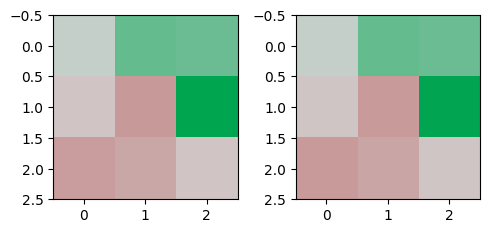

In [12]:
i = 3
print(codes[16])
S([recons[i].reshape(3,3), X[i].reshape(3,3)], mode=MODE)

0 0.9999873655876443


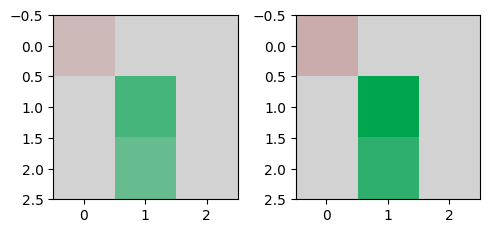

1 0.99999819221749


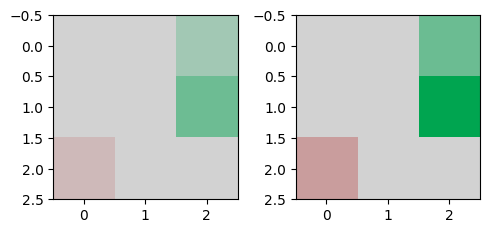

2 0.9988339716718612


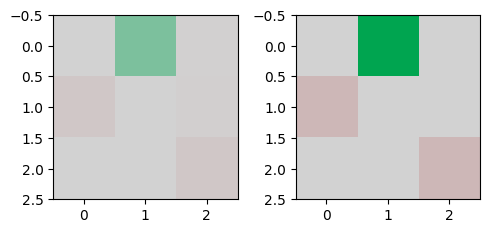

In [ ]:
components.shape, W_true
sims = np.abs(cosine_similarity(components, W_true))
pairs = []
for i in range(len(components)):
    j = np.argmax(sims[i])
    pairs.append((i, j, sims[i][j]))
for (i,j,score) in pairs:
    print(i, score)
    S([components[i].reshape(3,3), W_true[j].reshape(3,3)], mode=MODE)
    plt.show()

In [29]:
from sklearn import decomposition
# Global centering (focus on one feature, centering all samples)
means = X.mean(axis=0)
lin_pw_centered = X - means
# lin_pw_centered = X

# Local centering (focus on one sample, centering all features)
# lin_pw_centered -= lin_pw_centered.mean(axis=1).reshape(X.shape[0], -1)
ica_estimator = decomposition.FastICA(
    n_components=N_COMPS, max_iter=20000, whiten="arbitrary-variance", tol=15e-5
)
ica_estimator.fit(lin_pw_centered)

ica_codes = ica_estimator.transform(lin_pw_centered)
ica_recon = ica_estimator.inverse_transform(ica_codes)
ica_comps = ica_estimator.components_

array([<Axes: >, <Axes: >], dtype=object)

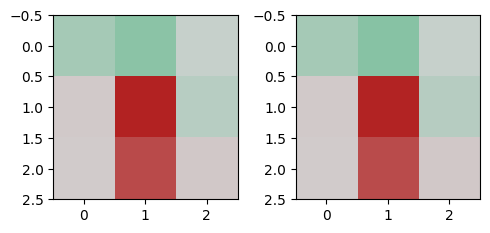

In [34]:
S([lin_pw_centered[0].reshape(3,3), X[0].reshape(3,3)], mode=MODE)

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

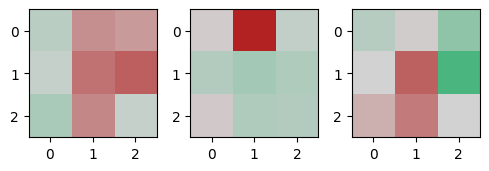

In [28]:
S([c.reshape(3,3) for c in ica_comps], ncols=3, mode=MODE)

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

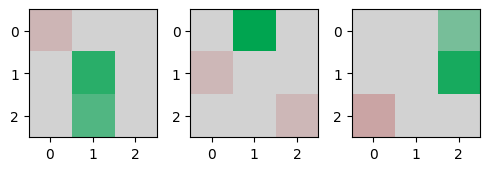

In [36]:
S([c.reshape(3,3) for c in W_true], ncols=3, mode=MODE)

In [37]:
W_true[2]

array([ 0.        ,  0.        ,  0.42224942,  0.        ,  0.        ,
        0.86889694, -0.25830898,  0.        ,  0.        ])

In [35]:
ica_comps

array([[-0.00132158, -0.0287445 ,  0.00213728,  0.00444425,  0.00622669,
         0.004393  , -0.0012949 ,  0.0047699 ,  0.00442425],
       [ 0.003363  , -0.01051183, -0.00912579,  0.0016119 , -0.01581195,
        -0.01879599,  0.00559273, -0.01213882,  0.00161303],
       [-0.00395093,  0.00135573, -0.0089547 , -0.00019512,  0.01845572,
        -0.01839714,  0.00547897,  0.01414756, -0.00021372]])

In [ ]:
upper, stability_score, _, pairwise_sims = hungarian_match(all_components)
print(stability_score)
plt.imshow(pairwise_sims, cmap="gray", vmin=0, vmax=1)
plt.show()

In [ ]:
show_gram(torch.tensor(components.T))

# Try on sklearn

## olivetti

In [10]:
import logging

import matplotlib.pyplot as plt
from numpy.random import RandomState

from sklearn import cluster, decomposition
from sklearn.datasets import fetch_olivetti_faces

rng = RandomState(0)

# Display progress logs on stdout
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=rng)
n_samples, n_features = faces.shape

# Global centering (focus on one feature, centering all samples)
faces_centered = faces - faces.mean(axis=0)

# Local centering (focus on one sample, centering all features)
faces_centered -= faces_centered.mean(axis=1).reshape(n_samples, -1)

print("Dataset consists of %d faces" % n_samples)

Dataset consists of 400 faces


In [11]:
n_row, n_col = 1,3
n_components = n_row * n_col
image_shape = (64, 64)


def plot_gallery(title, images, n_col=n_col, n_row=n_row, cmap=plt.cm.gray):
    fig, axs = plt.subplots(
        nrows=n_row,
        ncols=n_col,
        figsize=(2.0 * n_col, 2.3 * n_row),
        facecolor="white",
        constrained_layout=True,
    )
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0)
    fig.set_edgecolor("black")
    fig.suptitle(title, size=16)
    for ax, vec in zip(axs.flat, images):
        vmax = max(vec.max(), -vec.min())
        im = ax.imshow(
            vec.reshape(image_shape),
            cmap=cmap,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
        )
        ax.axis("off")

    fig.colorbar(im, ax=axs, orientation="horizontal", shrink=0.99, aspect=40, pad=0.01)
    plt.show()

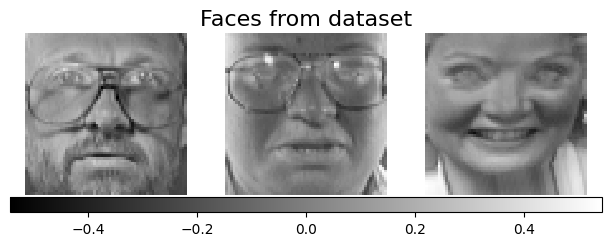

In [12]:
plot_gallery("Faces from dataset", faces_centered[:n_components])

In [ ]:
plot_gallery("our model", components[:n_components])

In [14]:
# simplified linear model
# see what noise we can expect from this model, easy
model, codes, components, recon = train_baseline(faces, n_components, epochs=5000)

finetune epoch    0 | recon_loss 6504.5659
finetune epoch  200 | recon_loss 379.0158
finetune epoch  400 | recon_loss 65.5148
finetune epoch  600 | recon_loss 60.2626
finetune epoch  800 | recon_loss 62.7216
finetune epoch 1000 | recon_loss 64.0820
finetune epoch 1200 | recon_loss 59.3416
finetune epoch 1400 | recon_loss 66.7397
finetune epoch 1600 | recon_loss 77.4931
finetune epoch 1800 | recon_loss 68.8130
finetune epoch 2000 | recon_loss 69.3146
finetune epoch 2200 | recon_loss 60.8304
finetune epoch 2400 | recon_loss 61.1356
finetune epoch 2600 | recon_loss 55.7973
finetune epoch 2800 | recon_loss 47.6243
finetune epoch 3000 | recon_loss 51.0659
finetune epoch 3200 | recon_loss 48.9454
finetune epoch 3400 | recon_loss 47.4862
finetune epoch 3600 | recon_loss 47.6699
finetune epoch 3800 | recon_loss 45.0408
finetune epoch 4000 | recon_loss 44.0910
finetune epoch 4200 | recon_loss 42.1962
finetune epoch 4400 | recon_loss 44.7225
finetune epoch 4600 | recon_loss 44.9310
finetune epoc

In [17]:
base_noise_std = np.std(faces - recon)

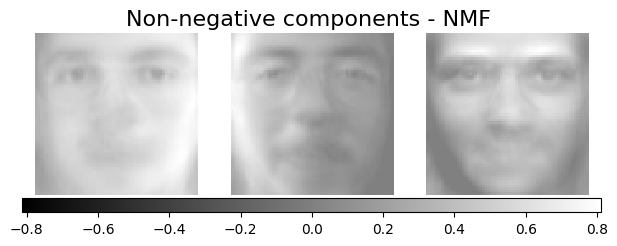

In [15]:
nmf_estimator = decomposition.NMF(n_components=n_components, tol=5e-3)
nmf_estimator.fit(faces)  # original non- negative dataset
plot_gallery("Non-negative components - NMF", nmf_estimator.components_[:n_components])

epoch    0 | recon_loss 99866.7891 weight_loss 243044416.0000 codes_loss 0.3539
epoch  200 | recon_loss 27248.6855 weight_loss 29223.6367 codes_loss 395.5266
epoch  400 | recon_loss 13631.4053 weight_loss 18869.9551 codes_loss 1254.1390
epoch  600 | recon_loss 13620.3418 weight_loss 15524.1348 codes_loss 1788.7098
epoch  800 | recon_loss 16466.8555 weight_loss 13803.7109 codes_loss 2088.8982
epoch 1000 | recon_loss 17610.9590 weight_loss 11588.5869 codes_loss 2235.0625
epoch 1200 | recon_loss 18721.3398 weight_loss 12176.2021 codes_loss 2313.5054
epoch 1400 | recon_loss 15758.0918 weight_loss 13220.5938 codes_loss 2319.5403
epoch 1600 | recon_loss 16077.3252 weight_loss 11709.2910 codes_loss 2294.7671
epoch 1800 | recon_loss 14719.0107 weight_loss 13970.2373 codes_loss 2264.6741
epoch 2000 | recon_loss 20020.4980 weight_loss 14966.0732 codes_loss 2233.8525
epoch 2200 | recon_loss 16433.2305 weight_loss 14587.1973 codes_loss 2224.7952
epoch 2400 | recon_loss 17503.4238 weight_loss 12755

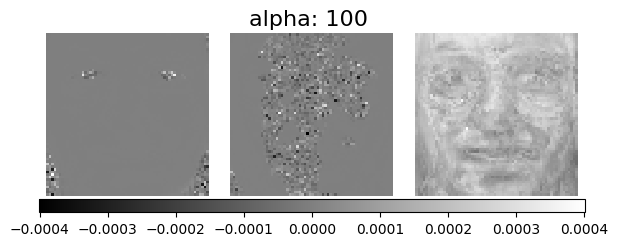

epoch    0 | recon_loss 100765.7266 weight_loss 255494944.0000 codes_loss 0.3493
epoch  200 | recon_loss 58915.0469 weight_loss 26600.1797 codes_loss 148.4273
epoch  400 | recon_loss 15041.8857 weight_loss 20894.2422 codes_loss 1012.4686
epoch  600 | recon_loss 13630.6709 weight_loss 18521.5527 codes_loss 1574.6603
epoch  800 | recon_loss 14957.6104 weight_loss 16273.5820 codes_loss 1900.0573
epoch 1000 | recon_loss 14915.4531 weight_loss 15143.3867 codes_loss 2084.3074
epoch 1200 | recon_loss 15591.3691 weight_loss 13416.9707 codes_loss 2189.4641
epoch 1400 | recon_loss 19555.1914 weight_loss 12191.7988 codes_loss 2243.7144
epoch 1600 | recon_loss 18498.7617 weight_loss 13550.8340 codes_loss 2279.1619
epoch 1800 | recon_loss 16859.7383 weight_loss 14365.8477 codes_loss 2277.5735
epoch 2000 | recon_loss 17282.3086 weight_loss 13153.8564 codes_loss 2235.0784
epoch 2200 | recon_loss 16495.8145 weight_loss 12910.5557 codes_loss 2238.0190
epoch 2400 | recon_loss 13455.2412 weight_loss 1329

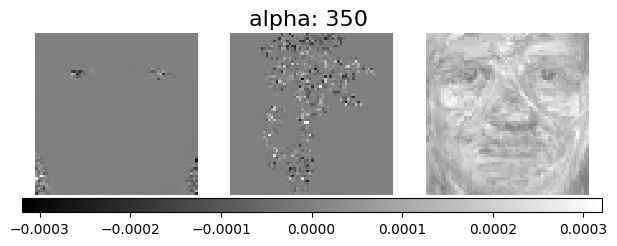

epoch    0 | recon_loss 104219.6016 weight_loss 267945504.0000 codes_loss 0.3480
epoch  200 | recon_loss 42513.2383 weight_loss 29576.3477 codes_loss 229.7359
epoch  400 | recon_loss 14166.7539 weight_loss 19847.8906 codes_loss 1071.5472
epoch  600 | recon_loss 13911.4600 weight_loss 16426.4922 codes_loss 1630.3121
epoch  800 | recon_loss 16947.7539 weight_loss 14644.1875 codes_loss 1967.9258
epoch 1000 | recon_loss 14626.7686 weight_loss 13440.2812 codes_loss 2159.9014
epoch 1200 | recon_loss 15216.0361 weight_loss 12989.9961 codes_loss 2269.4092
epoch 1400 | recon_loss 19858.6738 weight_loss 14105.9248 codes_loss 2315.9370
epoch 1600 | recon_loss 16849.9746 weight_loss 12963.9248 codes_loss 2318.7893
epoch 1800 | recon_loss 16282.4326 weight_loss 11727.2432 codes_loss 2288.5317
epoch 2000 | recon_loss 17527.2949 weight_loss 12316.1416 codes_loss 2284.7888
epoch 2200 | recon_loss 13961.5781 weight_loss 14004.3848 codes_loss 2242.2378
epoch 2400 | recon_loss 17376.6973 weight_loss 1204

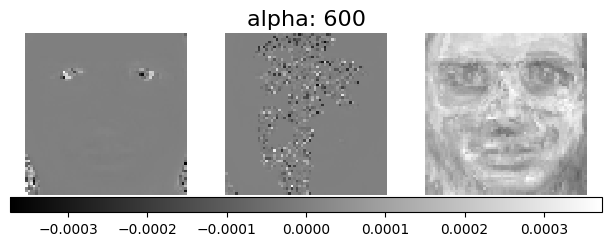

epoch    0 | recon_loss 102315.1875 weight_loss 280396096.0000 codes_loss 0.3457
epoch  200 | recon_loss 61473.9492 weight_loss 25884.5605 codes_loss 137.0007
epoch  400 | recon_loss 13895.6416 weight_loss 22159.1133 codes_loss 955.8364
epoch  600 | recon_loss 15777.6045 weight_loss 15446.9199 codes_loss 1535.6479
epoch  800 | recon_loss 13602.2402 weight_loss 15667.9863 codes_loss 1912.1832
epoch 1000 | recon_loss 14352.8174 weight_loss 14039.0430 codes_loss 2148.0808
epoch 1200 | recon_loss 18802.0000 weight_loss 14325.1846 codes_loss 2277.0491
epoch 1400 | recon_loss 14613.8350 weight_loss 13566.7930 codes_loss 2332.4299
epoch 1600 | recon_loss 17249.3750 weight_loss 11102.3203 codes_loss 2344.6965
epoch 1800 | recon_loss 14991.2637 weight_loss 11650.9961 codes_loss 2298.9944
epoch 2000 | recon_loss 15655.3262 weight_loss 13010.0176 codes_loss 2276.0706
epoch 2200 | recon_loss 18591.4551 weight_loss 13166.2910 codes_loss 2250.1577
epoch 2400 | recon_loss 16423.7910 weight_loss 12617

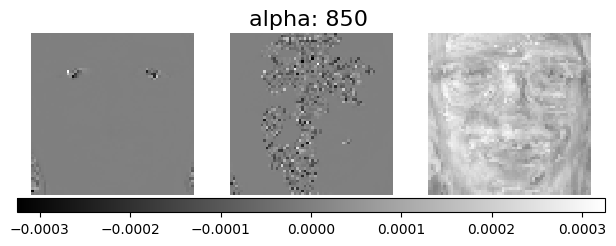

epoch    0 | recon_loss 101686.0859 weight_loss 292846688.0000 codes_loss 0.3508
epoch  200 | recon_loss 58034.9102 weight_loss 26972.4961 codes_loss 148.2607
epoch  400 | recon_loss 14550.1729 weight_loss 21333.4395 codes_loss 960.1946
epoch  600 | recon_loss 12737.1758 weight_loss 17829.9434 codes_loss 1541.8282
epoch  800 | recon_loss 12070.8535 weight_loss 15205.3848 codes_loss 1924.6538
epoch 1000 | recon_loss 19776.3477 weight_loss 13936.7109 codes_loss 2163.4885
epoch 1200 | recon_loss 16898.2539 weight_loss 12693.7305 codes_loss 2289.1902
epoch 1400 | recon_loss 13954.0859 weight_loss 13617.2744 codes_loss 2337.2375
epoch 1600 | recon_loss 15665.7012 weight_loss 13967.4424 codes_loss 2363.9592
epoch 1800 | recon_loss 26588.7656 weight_loss 11621.7324 codes_loss 2335.9919
epoch 2000 | recon_loss 14380.5684 weight_loss 12301.5332 codes_loss 2287.1462
epoch 2200 | recon_loss 15599.7627 weight_loss 12524.1250 codes_loss 2256.0283
epoch 2400 | recon_loss 15433.0576 weight_loss 15429

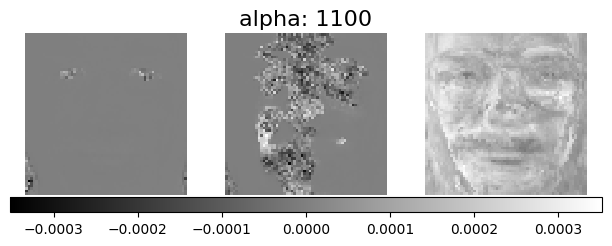

epoch    0 | recon_loss 98398.6562 weight_loss 305297344.0000 codes_loss 0.3505
epoch  200 | recon_loss 29988.2051 weight_loss 29393.5840 codes_loss 360.6858
epoch  400 | recon_loss 12299.7568 weight_loss 19094.8906 codes_loss 1178.2792
epoch  600 | recon_loss 12382.7275 weight_loss 15907.4395 codes_loss 1743.0801
epoch  800 | recon_loss 12976.3145 weight_loss 13290.1143 codes_loss 2104.2087
epoch 1000 | recon_loss 14483.8447 weight_loss 13382.1387 codes_loss 2311.1858
epoch 1200 | recon_loss 15505.7500 weight_loss 12698.4834 codes_loss 2405.7961
epoch 1400 | recon_loss 15098.1982 weight_loss 11546.9521 codes_loss 2423.8440
epoch 1600 | recon_loss 13808.8535 weight_loss 10858.0527 codes_loss 2401.0933
epoch 1800 | recon_loss 14973.9395 weight_loss 12667.5176 codes_loss 2365.5337
epoch 2000 | recon_loss 18026.9941 weight_loss 12384.9678 codes_loss 2313.9265
epoch 2200 | recon_loss 15042.8340 weight_loss 13460.5410 codes_loss 2276.9133
epoch 2400 | recon_loss 17360.3809 weight_loss 12423

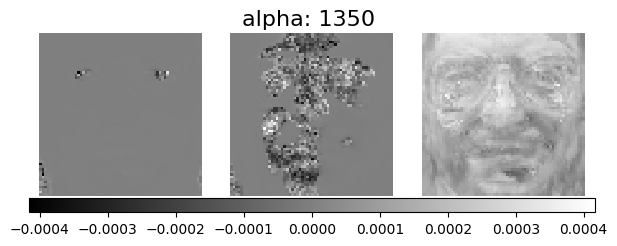

epoch    0 | recon_loss 101699.1250 weight_loss 317748032.0000 codes_loss 0.3481
epoch  200 | recon_loss 58735.4648 weight_loss 27031.3711 codes_loss 147.7771
epoch  400 | recon_loss 13854.6934 weight_loss 22120.8730 codes_loss 972.9810
epoch  600 | recon_loss 15441.7656 weight_loss 16762.7715 codes_loss 1545.1605
epoch  800 | recon_loss 16063.0098 weight_loss 15573.3945 codes_loss 1877.0380
epoch 1000 | recon_loss 19124.1992 weight_loss 13466.1797 codes_loss 2032.0326
epoch 1200 | recon_loss 15050.4043 weight_loss 13705.4287 codes_loss 2112.2700
epoch 1400 | recon_loss 27060.9512 weight_loss 11530.1562 codes_loss 2155.2170
epoch 1600 | recon_loss 19240.3262 weight_loss 12615.9795 codes_loss 2187.0977
epoch 1800 | recon_loss 22698.6875 weight_loss 13144.7266 codes_loss 2230.0732
epoch 2000 | recon_loss 16731.3867 weight_loss 12551.5527 codes_loss 2271.8096
epoch 2200 | recon_loss 14508.6484 weight_loss 13586.2246 codes_loss 2257.4863
epoch 2400 | recon_loss 21817.5918 weight_loss 12209

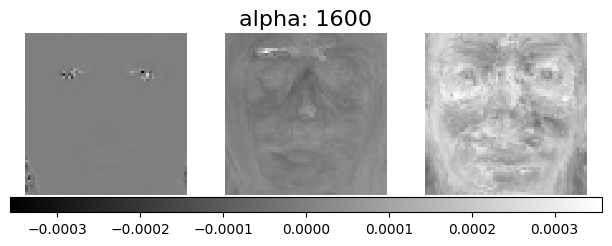

epoch    0 | recon_loss 103019.6953 weight_loss 330198688.0000 codes_loss 0.3463
epoch  200 | recon_loss 27760.4785 weight_loss 29546.3594 codes_loss 377.2198
epoch  400 | recon_loss 13449.2334 weight_loss 19163.7891 codes_loss 1185.5076
epoch  600 | recon_loss 11988.1758 weight_loss 15816.0186 codes_loss 1752.6201
epoch  800 | recon_loss 13321.6992 weight_loss 12742.1660 codes_loss 2120.4480
epoch 1000 | recon_loss 13386.7002 weight_loss 12789.5078 codes_loss 2336.2024
epoch 1200 | recon_loss 15670.0596 weight_loss 12346.4922 codes_loss 2442.4041
epoch 1400 | recon_loss 19789.3535 weight_loss 11004.2539 codes_loss 2478.5605
epoch 1600 | recon_loss 12996.9443 weight_loss 12982.6572 codes_loss 2444.2893
epoch 1800 | recon_loss 15809.4766 weight_loss 12996.7754 codes_loss 2407.1074
epoch 2000 | recon_loss 14233.5371 weight_loss 14360.8750 codes_loss 2371.2063
epoch 2200 | recon_loss 15503.5713 weight_loss 12580.2168 codes_loss 2308.6555
epoch 2400 | recon_loss 11853.4824 weight_loss 1381

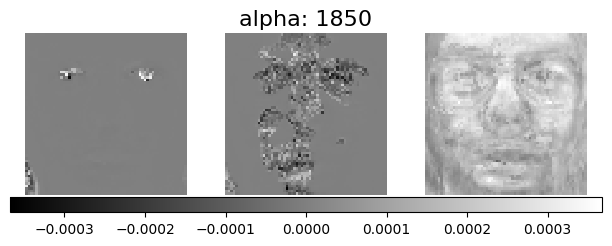

epoch    0 | recon_loss 104488.8281 weight_loss 342649408.0000 codes_loss 0.3526
epoch  200 | recon_loss 37513.7656 weight_loss 30087.4609 codes_loss 269.3210
epoch  400 | recon_loss 12738.5742 weight_loss 21142.6016 codes_loss 1076.7034
epoch  600 | recon_loss 12578.4492 weight_loss 15840.3398 codes_loss 1649.4760
epoch  800 | recon_loss 18757.7676 weight_loss 13749.6992 codes_loss 2011.7139
epoch 1000 | recon_loss 14583.7178 weight_loss 13974.9844 codes_loss 2229.6201
epoch 1200 | recon_loss 14167.2832 weight_loss 13947.7686 codes_loss 2347.9719
epoch 1400 | recon_loss 15409.8828 weight_loss 11964.8223 codes_loss 2405.1453
epoch 1600 | recon_loss 13618.3691 weight_loss 11954.6973 codes_loss 2426.9138
epoch 1800 | recon_loss 16381.9668 weight_loss 12079.6416 codes_loss 2407.8274
epoch 2000 | recon_loss 13028.1689 weight_loss 14009.0205 codes_loss 2329.9373
epoch 2200 | recon_loss 15067.8730 weight_loss 13085.1621 codes_loss 2321.0815
epoch 2400 | recon_loss 15265.5713 weight_loss 1368

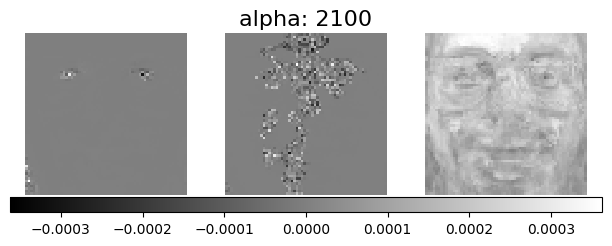

epoch    0 | recon_loss 98594.3516 weight_loss 355100096.0000 codes_loss 0.3498
epoch  200 | recon_loss 29473.8359 weight_loss 29201.2031 codes_loss 374.7841
epoch  400 | recon_loss 12487.1816 weight_loss 19252.6777 codes_loss 1176.7424
epoch  600 | recon_loss 13324.2783 weight_loss 15742.9102 codes_loss 1749.3551
epoch  800 | recon_loss 12654.7979 weight_loss 13307.5938 codes_loss 2127.4382
epoch 1000 | recon_loss 17401.6133 weight_loss 10526.4346 codes_loss 2356.4866
epoch 1200 | recon_loss 14219.2314 weight_loss 12589.0732 codes_loss 2471.1692
epoch 1400 | recon_loss 16234.8818 weight_loss 10108.7822 codes_loss 2498.9119
epoch 1600 | recon_loss 13493.4814 weight_loss 12909.8350 codes_loss 2493.2498
epoch 1800 | recon_loss 14456.5361 weight_loss 12785.1367 codes_loss 2440.9614
epoch 2000 | recon_loss 18712.3340 weight_loss 11010.5908 codes_loss 2408.9653
epoch 2200 | recon_loss 16555.1758 weight_loss 12074.1816 codes_loss 2346.5432
epoch 2400 | recon_loss 15790.5293 weight_loss 13438

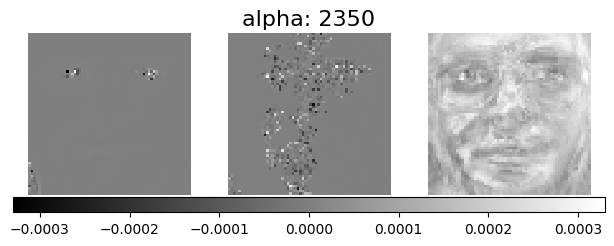

epoch    0 | recon_loss 101176.7031 weight_loss 367550848.0000 codes_loss 0.3492
epoch  200 | recon_loss 52943.9844 weight_loss 28269.1074 codes_loss 178.8204
epoch  400 | recon_loss 13338.3076 weight_loss 21607.6602 codes_loss 968.1685
epoch  600 | recon_loss 13888.0586 weight_loss 16897.2344 codes_loss 1553.5444
epoch  800 | recon_loss 12450.9238 weight_loss 15379.0781 codes_loss 1934.3197
epoch 1000 | recon_loss 14619.7217 weight_loss 14050.0713 codes_loss 2168.9509
epoch 1200 | recon_loss 16688.7305 weight_loss 11309.0596 codes_loss 2295.6995
epoch 1400 | recon_loss 19938.7539 weight_loss 11456.1914 codes_loss 2381.4377
epoch 1600 | recon_loss 17223.3477 weight_loss 10999.9434 codes_loss 2421.5146
epoch 1800 | recon_loss 15611.2451 weight_loss 12060.8496 codes_loss 2419.2070
epoch 2000 | recon_loss 15919.3633 weight_loss 12693.9219 codes_loss 2389.9792
epoch 2200 | recon_loss 17401.5098 weight_loss 12870.7988 codes_loss 2339.4275
epoch 2400 | recon_loss 15477.8721 weight_loss 12452

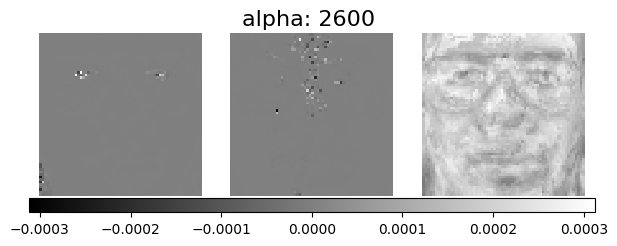

epoch    0 | recon_loss 99566.7734 weight_loss 380001600.0000 codes_loss 0.3492
epoch  200 | recon_loss 26188.6211 weight_loss 28702.7852 codes_loss 419.1586
epoch  400 | recon_loss 12882.3408 weight_loss 18268.8203 codes_loss 1219.7041
epoch  600 | recon_loss 12372.3379 weight_loss 14638.8379 codes_loss 1795.6320
epoch  800 | recon_loss 14159.1260 weight_loss 12231.8691 codes_loss 2168.1580
epoch 1000 | recon_loss 15092.6377 weight_loss 12367.8340 codes_loss 2391.3171
epoch 1200 | recon_loss 13250.2998 weight_loss 12290.0020 codes_loss 2505.8289
epoch 1400 | recon_loss 18622.9160 weight_loss 11978.7969 codes_loss 2534.0532
epoch 1600 | recon_loss 15609.0859 weight_loss 12748.5518 codes_loss 2519.2896
epoch 1800 | recon_loss 12382.5479 weight_loss 11736.6680 codes_loss 2479.2300
epoch 2000 | recon_loss 17310.2188 weight_loss 10963.3984 codes_loss 2416.8972
epoch 2200 | recon_loss 15744.1680 weight_loss 14148.4990 codes_loss 2365.9023
epoch 2400 | recon_loss 20544.8887 weight_loss 12741

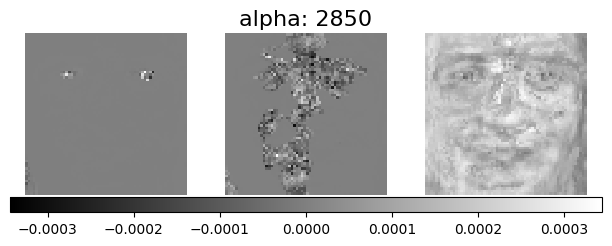

epoch    0 | recon_loss 97723.8281 weight_loss 392452352.0000 codes_loss 0.3501
epoch  200 | recon_loss 50394.4258 weight_loss 28554.2559 codes_loss 189.6878
epoch  400 | recon_loss 13891.1846 weight_loss 21420.6289 codes_loss 993.8113
epoch  600 | recon_loss 14495.8311 weight_loss 16208.8301 codes_loss 1579.9203
epoch  800 | recon_loss 14752.6299 weight_loss 13780.4004 codes_loss 1946.1869
epoch 1000 | recon_loss 13651.9375 weight_loss 14209.1348 codes_loss 2135.3401
epoch 1200 | recon_loss 15203.7881 weight_loss 13049.2148 codes_loss 2225.4275
epoch 1400 | recon_loss 18978.1152 weight_loss 12909.7344 codes_loss 2278.4824
epoch 1600 | recon_loss 16938.5645 weight_loss 12173.6504 codes_loss 2308.0007
epoch 1800 | recon_loss 13848.4443 weight_loss 12630.7402 codes_loss 2344.6160
epoch 2000 | recon_loss 17841.7949 weight_loss 11797.2656 codes_loss 2378.3105
epoch 2200 | recon_loss 12092.1680 weight_loss 12515.4375 codes_loss 2324.5261
epoch 2400 | recon_loss 17584.7129 weight_loss 12978.

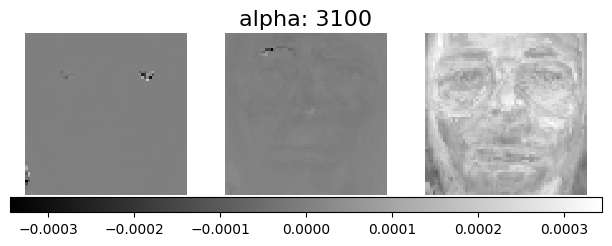

epoch    0 | recon_loss 100073.2188 weight_loss 404903136.0000 codes_loss 0.3470
epoch  200 | recon_loss 32589.6191 weight_loss 30293.4082 codes_loss 307.1736
epoch  400 | recon_loss 11973.9346 weight_loss 20390.6250 codes_loss 1093.6893
epoch  600 | recon_loss 11838.1162 weight_loss 15644.0459 codes_loss 1678.1562
epoch  800 | recon_loss 10857.1367 weight_loss 14957.1865 codes_loss 2082.1160
epoch 1000 | recon_loss 12669.8008 weight_loss 13526.9170 codes_loss 2338.6680
epoch 1200 | recon_loss 16610.5879 weight_loss 10779.5361 codes_loss 2482.7114
epoch 1400 | recon_loss 14347.5381 weight_loss 11641.2324 codes_loss 2547.3755
epoch 1600 | recon_loss 19563.2949 weight_loss 10360.0264 codes_loss 2551.7415
epoch 1800 | recon_loss 19108.0566 weight_loss 11199.9688 codes_loss 2501.3313
epoch 2000 | recon_loss 19756.0840 weight_loss 12448.9277 codes_loss 2452.0256
epoch 2200 | recon_loss 14495.2490 weight_loss 12634.7725 codes_loss 2366.2134
epoch 2400 | recon_loss 14238.7568 weight_loss 1325

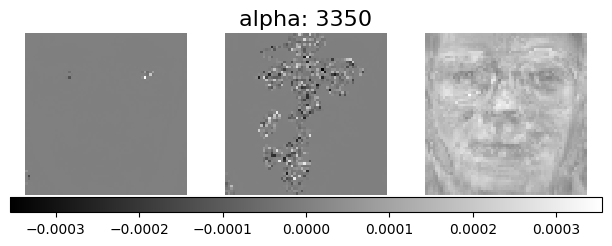

epoch    0 | recon_loss 99110.1875 weight_loss 417353920.0000 codes_loss 0.3478
epoch  200 | recon_loss 39126.1211 weight_loss 29764.2109 codes_loss 258.0433
epoch  400 | recon_loss 13234.2617 weight_loss 20324.1562 codes_loss 1051.8325
epoch  600 | recon_loss 12827.6650 weight_loss 15615.4443 codes_loss 1635.4346
epoch  800 | recon_loss 11824.3770 weight_loss 14680.6035 codes_loss 2019.8989
epoch 1000 | recon_loss 14487.2266 weight_loss 12512.5059 codes_loss 2241.8923
epoch 1200 | recon_loss 15676.8809 weight_loss 13302.8135 codes_loss 2377.0618
epoch 1400 | recon_loss 13283.4912 weight_loss 11750.0625 codes_loss 2445.4470
epoch 1600 | recon_loss 14920.5918 weight_loss 11561.5293 codes_loss 2476.1438
epoch 1800 | recon_loss 17644.3535 weight_loss 11388.1328 codes_loss 2485.0291
epoch 2000 | recon_loss 19190.4570 weight_loss 10778.7793 codes_loss 2442.5989
epoch 2200 | recon_loss 13023.2031 weight_loss 11858.2832 codes_loss 2393.9009
epoch 2400 | recon_loss 17305.1328 weight_loss 12743

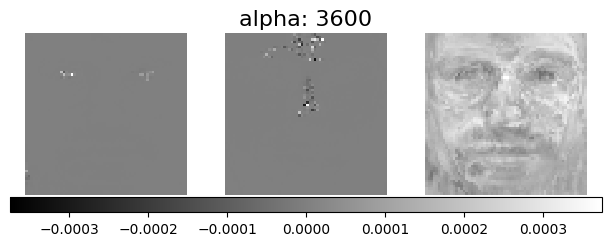

epoch    0 | recon_loss 102116.1562 weight_loss 429804736.0000 codes_loss 0.3500
epoch  200 | recon_loss 43880.3438 weight_loss 29352.5664 codes_loss 228.7261
epoch  400 | recon_loss 12815.2676 weight_loss 21040.0273 codes_loss 1028.1346
epoch  600 | recon_loss 13296.3320 weight_loss 15665.6680 codes_loss 1617.7909
epoch  800 | recon_loss 13448.1768 weight_loss 15652.2812 codes_loss 1989.1193
epoch 1000 | recon_loss 13070.8613 weight_loss 13284.9824 codes_loss 2192.8267
epoch 1200 | recon_loss 18249.6504 weight_loss 13887.7549 codes_loss 2301.4907
epoch 1400 | recon_loss 15295.5859 weight_loss 12025.8506 codes_loss 2348.9631
epoch 1600 | recon_loss 14551.1943 weight_loss 12927.1406 codes_loss 2377.8655
epoch 1800 | recon_loss 15551.3594 weight_loss 11917.1533 codes_loss 2403.8313
epoch 2000 | recon_loss 14688.4551 weight_loss 11935.7197 codes_loss 2402.4299
epoch 2200 | recon_loss 15704.4639 weight_loss 12690.7070 codes_loss 2398.2253
epoch 2400 | recon_loss 20922.9902 weight_loss 1269

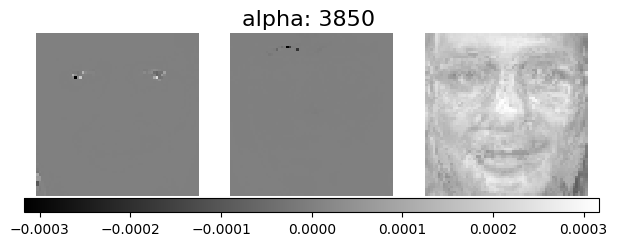

epoch    0 | recon_loss 103600.8750 weight_loss 442255456.0000 codes_loss 0.3471
epoch  200 | recon_loss 28705.8887 weight_loss 29590.1680 codes_loss 363.6805
epoch  400 | recon_loss 12046.9795 weight_loss 19844.3906 codes_loss 1150.5614
epoch  600 | recon_loss 12405.5771 weight_loss 15216.7285 codes_loss 1737.6417
epoch  800 | recon_loss 13651.0498 weight_loss 12518.1895 codes_loss 2140.9534
epoch 1000 | recon_loss 14486.7891 weight_loss 11749.8506 codes_loss 2393.2314
epoch 1200 | recon_loss 14438.9912 weight_loss 12585.3711 codes_loss 2536.8147
epoch 1400 | recon_loss 16014.8613 weight_loss 11122.7383 codes_loss 2593.9961
epoch 1600 | recon_loss 12576.2295 weight_loss 12140.7832 codes_loss 2575.8550
epoch 1800 | recon_loss 14617.4863 weight_loss 13483.4209 codes_loss 2541.0239
epoch 2000 | recon_loss 13629.6699 weight_loss 12325.7441 codes_loss 2502.0144
epoch 2200 | recon_loss 14682.8467 weight_loss 11416.0215 codes_loss 2423.3872
epoch 2400 | recon_loss 19727.3320 weight_loss 1186

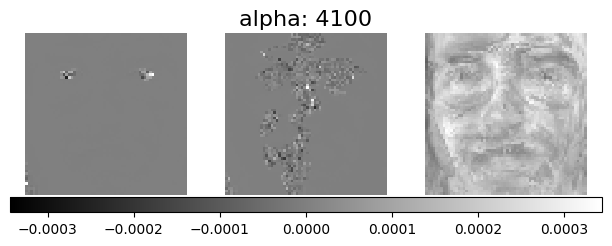

epoch    0 | recon_loss 101244.6719 weight_loss 454706304.0000 codes_loss 0.3492
epoch  200 | recon_loss 28641.8223 weight_loss 29926.4648 codes_loss 353.1816
epoch  400 | recon_loss 12230.9805 weight_loss 19152.9297 codes_loss 1136.4435
epoch  600 | recon_loss 11114.9785 weight_loss 15489.1348 codes_loss 1726.7646
epoch  800 | recon_loss 13511.2168 weight_loss 12367.0488 codes_loss 2141.3601
epoch 1000 | recon_loss 12710.3496 weight_loss 11675.3545 codes_loss 2395.6765
epoch 1200 | recon_loss 15700.3037 weight_loss 10440.2422 codes_loss 2547.6550
epoch 1400 | recon_loss 12058.8730 weight_loss 12719.1006 codes_loss 2611.6882
epoch 1600 | recon_loss 15902.3359 weight_loss 12386.0332 codes_loss 2611.2356
epoch 1800 | recon_loss 25087.4941 weight_loss 11118.3076 codes_loss 2562.7234
epoch 2000 | recon_loss 13480.6543 weight_loss 12217.3115 codes_loss 2508.0488
epoch 2200 | recon_loss 17943.4609 weight_loss 10614.5146 codes_loss 2433.9819
epoch 2400 | recon_loss 13470.4082 weight_loss 1295

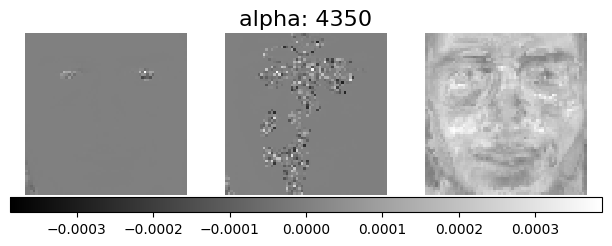

epoch    0 | recon_loss 98498.9062 weight_loss 467157088.0000 codes_loss 0.3546
epoch  200 | recon_loss 23823.6016 weight_loss 28330.2305 codes_loss 460.1051
epoch  400 | recon_loss 11690.1680 weight_loss 18522.0195 codes_loss 1254.3480
epoch  600 | recon_loss 14566.4668 weight_loss 14050.9902 codes_loss 1842.8320
epoch  800 | recon_loss 14616.7490 weight_loss 12655.5635 codes_loss 2239.2063
epoch 1000 | recon_loss 12627.6250 weight_loss 11509.9756 codes_loss 2479.2334
epoch 1200 | recon_loss 13106.5918 weight_loss 11209.6426 codes_loss 2602.8071
epoch 1400 | recon_loss 17099.3594 weight_loss 11600.2520 codes_loss 2656.2231
epoch 1600 | recon_loss 14151.3076 weight_loss 12955.2656 codes_loss 2639.3127
epoch 1800 | recon_loss 12736.6465 weight_loss 13180.0938 codes_loss 2588.1438
epoch 2000 | recon_loss 15197.3203 weight_loss 11223.5186 codes_loss 2527.8430
epoch 2200 | recon_loss 14642.4756 weight_loss 11872.3047 codes_loss 2459.1870
epoch 2400 | recon_loss 14418.9766 weight_loss 14157

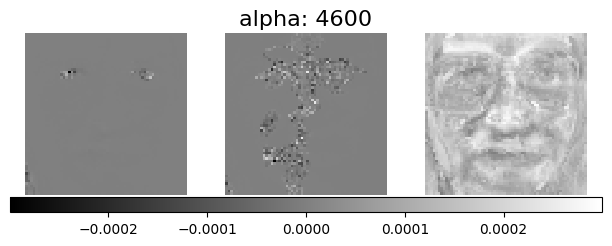

epoch    0 | recon_loss 102217.0547 weight_loss 479607936.0000 codes_loss 0.3470
epoch  200 | recon_loss 28259.9062 weight_loss 29366.0234 codes_loss 373.8567
epoch  400 | recon_loss 11572.2334 weight_loss 19461.5977 codes_loss 1157.4329
epoch  600 | recon_loss 12346.2793 weight_loss 14656.3652 codes_loss 1752.0726
epoch  800 | recon_loss 15113.8906 weight_loss 12095.5146 codes_loss 2168.0530
epoch 1000 | recon_loss 10744.7051 weight_loss 12032.2637 codes_loss 2428.1431
epoch 1200 | recon_loss 15170.8672 weight_loss 11261.6592 codes_loss 2571.5906
epoch 1400 | recon_loss 14262.5654 weight_loss 12149.9766 codes_loss 2628.0427
epoch 1600 | recon_loss 15171.9521 weight_loss 11136.3809 codes_loss 2633.5862
epoch 1800 | recon_loss 15583.7676 weight_loss 10637.2686 codes_loss 2573.7000
epoch 2000 | recon_loss 14574.8691 weight_loss 12679.4414 codes_loss 2507.0364
epoch 2200 | recon_loss 16449.8789 weight_loss 12937.8213 codes_loss 2478.8953
epoch 2400 | recon_loss 18445.2285 weight_loss 1361

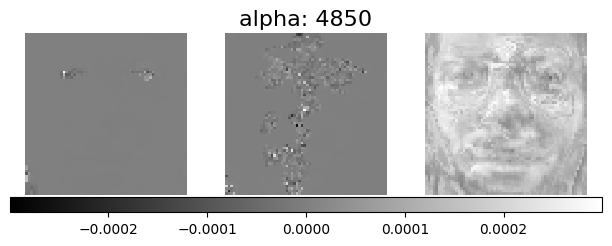

epoch    0 | recon_loss 101341.0156 weight_loss 492058752.0000 codes_loss 0.3549
epoch  200 | recon_loss 23229.7559 weight_loss 28408.5723 codes_loss 461.1470
epoch  400 | recon_loss 11454.5361 weight_loss 18419.4023 codes_loss 1256.0084
epoch  600 | recon_loss 11323.3867 weight_loss 14576.7764 codes_loss 1846.4425
epoch  800 | recon_loss 12730.5020 weight_loss 13113.7939 codes_loss 2245.3435
epoch 1000 | recon_loss 13208.4570 weight_loss 11969.7227 codes_loss 2480.4646
epoch 1200 | recon_loss 12072.4521 weight_loss 11223.4492 codes_loss 2611.5850
epoch 1400 | recon_loss 13312.8896 weight_loss 11450.4180 codes_loss 2665.2473
epoch 1600 | recon_loss 12838.7129 weight_loss 11451.0361 codes_loss 2661.0427
epoch 1800 | recon_loss 13031.3164 weight_loss 11316.7607 codes_loss 2595.3945
epoch 2000 | recon_loss 14232.4668 weight_loss 11606.0996 codes_loss 2542.0005
epoch 2200 | recon_loss 14064.5947 weight_loss 12615.2334 codes_loss 2477.7556
epoch 2400 | recon_loss 15915.8584 weight_loss 1187

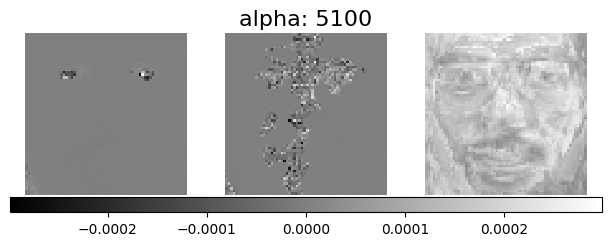

epoch    0 | recon_loss 101328.8672 weight_loss 504509568.0000 codes_loss 0.3496
epoch  200 | recon_loss 37116.5117 weight_loss 29881.5410 codes_loss 280.1906
epoch  400 | recon_loss 12953.9170 weight_loss 20508.3398 codes_loss 1055.0228
epoch  600 | recon_loss 11006.6436 weight_loss 16374.9639 codes_loss 1651.3639
epoch  800 | recon_loss 14469.1621 weight_loss 13270.3643 codes_loss 2076.1519
epoch 1000 | recon_loss 13835.5078 weight_loss 12758.4102 codes_loss 2345.9636
epoch 1200 | recon_loss 13887.6143 weight_loss 11552.0244 codes_loss 2511.4395
epoch 1400 | recon_loss 13746.1074 weight_loss 12586.5371 codes_loss 2590.5603
epoch 1600 | recon_loss 12578.4834 weight_loss 11990.5576 codes_loss 2621.3550
epoch 1800 | recon_loss 14313.5518 weight_loss 12978.7822 codes_loss 2586.9263
epoch 2000 | recon_loss 17183.4062 weight_loss 12305.0537 codes_loss 2541.8899
epoch 2200 | recon_loss 14560.1270 weight_loss 11387.5205 codes_loss 2481.3311
epoch 2400 | recon_loss 16708.8574 weight_loss 1177

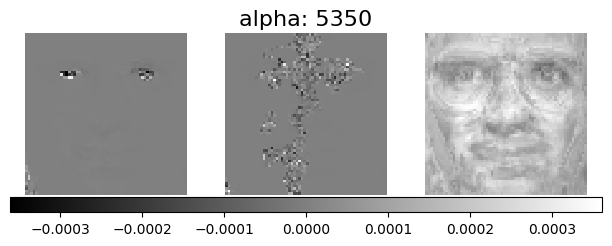

epoch    0 | recon_loss 101478.9531 weight_loss 516960416.0000 codes_loss 0.3510
epoch  200 | recon_loss 31561.3164 weight_loss 29800.4023 codes_loss 334.6870
epoch  400 | recon_loss 11939.5771 weight_loss 20047.7480 codes_loss 1121.2992
epoch  600 | recon_loss 14209.2432 weight_loss 15424.6152 codes_loss 1717.2168
epoch  800 | recon_loss 13443.3809 weight_loss 13675.4482 codes_loss 2123.7014
epoch 1000 | recon_loss 13832.1572 weight_loss 10999.7422 codes_loss 2377.7639
epoch 1200 | recon_loss 14457.8965 weight_loss 12440.1973 codes_loss 2509.2576
epoch 1400 | recon_loss 13956.7861 weight_loss 11664.2109 codes_loss 2577.0610
epoch 1600 | recon_loss 16573.4746 weight_loss 11876.3535 codes_loss 2603.3699
epoch 1800 | recon_loss 15844.5215 weight_loss 10868.4639 codes_loss 2612.9856
epoch 2000 | recon_loss 12768.3516 weight_loss 12084.7773 codes_loss 2552.0029
epoch 2200 | recon_loss 19329.1406 weight_loss 11291.9551 codes_loss 2502.0349
epoch 2400 | recon_loss 14098.1807 weight_loss 1213

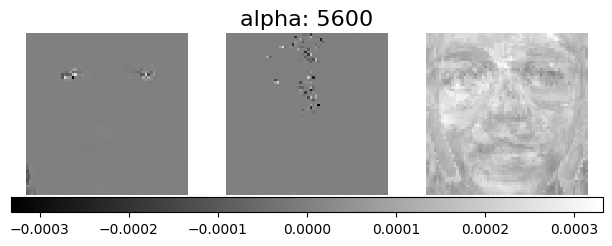

epoch    0 | recon_loss 99044.8281 weight_loss 529411264.0000 codes_loss 0.3519
epoch  200 | recon_loss 29737.8770 weight_loss 29722.2891 codes_loss 351.3396
epoch  400 | recon_loss 12291.6182 weight_loss 19871.8418 codes_loss 1130.0797
epoch  600 | recon_loss 11771.2402 weight_loss 14835.9150 codes_loss 1727.4580
epoch  800 | recon_loss 13955.0850 weight_loss 13501.3193 codes_loss 2156.7217
epoch 1000 | recon_loss 17011.8867 weight_loss 11365.5527 codes_loss 2431.9302
epoch 1200 | recon_loss 14523.0518 weight_loss 10743.5986 codes_loss 2591.1570
epoch 1400 | recon_loss 13162.3906 weight_loss 11779.0127 codes_loss 2667.4529
epoch 1600 | recon_loss 14751.3066 weight_loss 11289.4375 codes_loss 2675.3728
epoch 1800 | recon_loss 17747.9961 weight_loss 11007.6211 codes_loss 2639.0371
epoch 2000 | recon_loss 13518.3584 weight_loss 11350.5713 codes_loss 2560.9578
epoch 2200 | recon_loss 13274.9102 weight_loss 11478.6973 codes_loss 2508.5857
epoch 2400 | recon_loss 13198.1602 weight_loss 12520

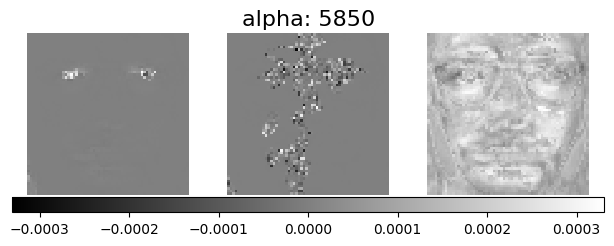

epoch    0 | recon_loss 98401.9609 weight_loss 541862080.0000 codes_loss 0.3517
epoch  200 | recon_loss 27943.2383 weight_loss 29446.4277 codes_loss 380.1949
epoch  400 | recon_loss 11557.1094 weight_loss 19290.4883 codes_loss 1161.4243
epoch  600 | recon_loss 9981.3145 weight_loss 15167.8154 codes_loss 1761.4995
epoch  800 | recon_loss 11573.1846 weight_loss 13582.7051 codes_loss 2189.4573
epoch 1000 | recon_loss 12347.5674 weight_loss 11685.5859 codes_loss 2463.0342
epoch 1200 | recon_loss 13915.2959 weight_loss 11444.0840 codes_loss 2621.1609
epoch 1400 | recon_loss 12917.9834 weight_loss 11886.0996 codes_loss 2690.5542
epoch 1600 | recon_loss 14149.5205 weight_loss 11169.2158 codes_loss 2684.9255
epoch 1800 | recon_loss 15225.1396 weight_loss 10994.3691 codes_loss 2654.1255
epoch 2000 | recon_loss 14244.4131 weight_loss 10379.0449 codes_loss 2598.7610
epoch 2200 | recon_loss 16615.9941 weight_loss 11979.4619 codes_loss 2526.3752
epoch 2400 | recon_loss 16637.9883 weight_loss 11217.

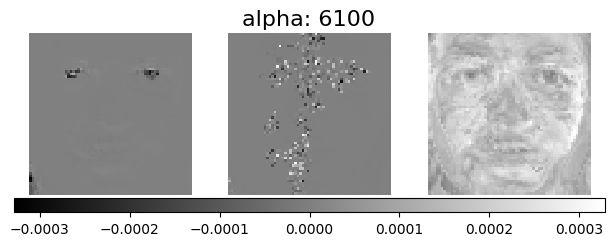

epoch    0 | recon_loss 97540.0156 weight_loss 554312960.0000 codes_loss 0.3543
epoch  200 | recon_loss 21809.9805 weight_loss 27514.9219 codes_loss 509.1111
epoch  400 | recon_loss 11265.0088 weight_loss 17573.7402 codes_loss 1307.1426
epoch  600 | recon_loss 11486.7627 weight_loss 14011.9531 codes_loss 1905.4413
epoch  800 | recon_loss 12254.4287 weight_loss 11863.5625 codes_loss 2317.6484
epoch 1000 | recon_loss 12476.4180 weight_loss 11533.6367 codes_loss 2563.1375
epoch 1200 | recon_loss 13044.4336 weight_loss 10833.5098 codes_loss 2686.0300
epoch 1400 | recon_loss 12462.0078 weight_loss 11071.8477 codes_loss 2735.2344
epoch 1600 | recon_loss 14167.5723 weight_loss 10662.5801 codes_loss 2727.6951
epoch 1800 | recon_loss 14867.0234 weight_loss 10392.8330 codes_loss 2694.0742
epoch 2000 | recon_loss 14008.6562 weight_loss 11958.9473 codes_loss 2589.0337
epoch 2200 | recon_loss 15047.5459 weight_loss 10827.5508 codes_loss 2535.2908
epoch 2400 | recon_loss 13282.9961 weight_loss 12730

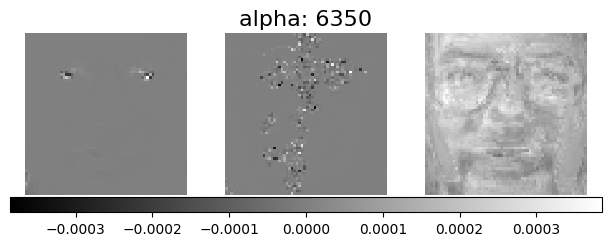

epoch    0 | recon_loss 102252.2188 weight_loss 566763776.0000 codes_loss 0.3447
epoch  200 | recon_loss 30844.9219 weight_loss 29778.4297 codes_loss 341.4182
epoch  400 | recon_loss 11963.7227 weight_loss 19685.8594 codes_loss 1124.9836
epoch  600 | recon_loss 10590.8623 weight_loss 15381.3682 codes_loss 1728.2843
epoch  800 | recon_loss 13385.2891 weight_loss 12619.9355 codes_loss 2147.1450
epoch 1000 | recon_loss 13551.0156 weight_loss 12273.0371 codes_loss 2414.4050
epoch 1200 | recon_loss 13336.6875 weight_loss 11177.2109 codes_loss 2565.8860
epoch 1400 | recon_loss 17066.5801 weight_loss 11523.3496 codes_loss 2648.5613
epoch 1600 | recon_loss 12867.4375 weight_loss 11415.3701 codes_loss 2662.0173
epoch 1800 | recon_loss 17892.2695 weight_loss 10292.4229 codes_loss 2662.8147
epoch 2000 | recon_loss 21508.0273 weight_loss 9809.9346 codes_loss 2614.4924
epoch 2200 | recon_loss 12619.8301 weight_loss 12009.1230 codes_loss 2552.9426
epoch 2400 | recon_loss 14469.0859 weight_loss 12859

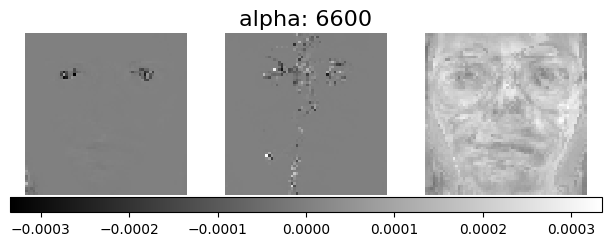

epoch    0 | recon_loss 101733.8203 weight_loss 579214656.0000 codes_loss 0.3443
epoch  200 | recon_loss 33999.6992 weight_loss 29995.7246 codes_loss 307.9384
epoch  400 | recon_loss 12208.3584 weight_loss 19535.9219 codes_loss 1122.1229
epoch  600 | recon_loss 11969.7393 weight_loss 15315.7383 codes_loss 1735.9601
epoch  800 | recon_loss 11938.6982 weight_loss 13740.2354 codes_loss 2128.1311
epoch 1000 | recon_loss 14376.6504 weight_loss 13008.1074 codes_loss 2341.6042
epoch 1200 | recon_loss 14362.0439 weight_loss 12134.1465 codes_loss 2421.9534
epoch 1400 | recon_loss 12291.3828 weight_loss 12341.8750 codes_loss 2444.1833
epoch 1600 | recon_loss 13010.6494 weight_loss 12682.1895 codes_loss 2440.9797
epoch 1800 | recon_loss 14271.9434 weight_loss 12871.7373 codes_loss 2483.4019
epoch 2000 | recon_loss 15770.9238 weight_loss 11116.0195 codes_loss 2480.5027
epoch 2200 | recon_loss 18816.2246 weight_loss 12310.4902 codes_loss 2482.0144
epoch 2400 | recon_loss 14930.7803 weight_loss 1304

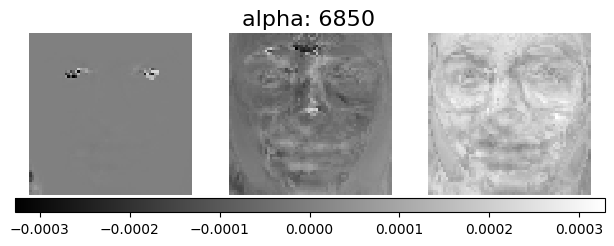

epoch    0 | recon_loss 107369.4453 weight_loss 591665600.0000 codes_loss 0.3449
epoch  200 | recon_loss 35998.8750 weight_loss 29800.0723 codes_loss 287.2983
epoch  400 | recon_loss 12269.3643 weight_loss 19974.9277 codes_loss 1052.4940
epoch  600 | recon_loss 11753.1553 weight_loss 16295.7510 codes_loss 1656.3379
epoch  800 | recon_loss 14444.6992 weight_loss 12834.8066 codes_loss 2107.6143
epoch 1000 | recon_loss 13284.9609 weight_loss 12684.2598 codes_loss 2412.8101
epoch 1200 | recon_loss 13527.3926 weight_loss 10623.1143 codes_loss 2603.3889
epoch 1400 | recon_loss 17324.8438 weight_loss 9875.6748 codes_loss 2674.1191
epoch 1600 | recon_loss 13374.4697 weight_loss 11744.6475 codes_loss 2703.9202
epoch 1800 | recon_loss 12750.2236 weight_loss 11391.5029 codes_loss 2687.3386
epoch 2000 | recon_loss 16325.9707 weight_loss 9775.3223 codes_loss 2632.4377
epoch 2200 | recon_loss 15426.4658 weight_loss 10655.5439 codes_loss 2565.1208
epoch 2400 | recon_loss 16277.2305 weight_loss 10643.

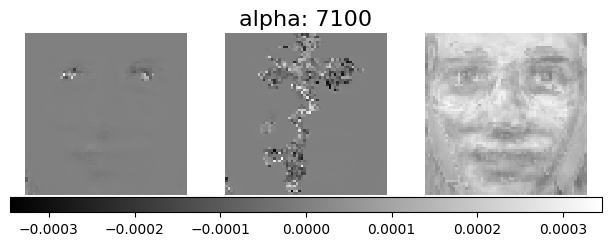

epoch    0 | recon_loss 99560.8906 weight_loss 604116416.0000 codes_loss 0.3494
epoch  200 | recon_loss 38085.7148 weight_loss 30271.2305 codes_loss 258.1064
epoch  400 | recon_loss 12500.7549 weight_loss 20638.5195 codes_loss 1016.9116
epoch  600 | recon_loss 10771.8008 weight_loss 15976.0547 codes_loss 1621.0132
epoch  800 | recon_loss 10920.4072 weight_loss 13487.9287 codes_loss 2072.8843
epoch 1000 | recon_loss 11351.1475 weight_loss 12654.0312 codes_loss 2382.9529
epoch 1200 | recon_loss 14072.3398 weight_loss 10840.3535 codes_loss 2579.3206
epoch 1400 | recon_loss 11972.1094 weight_loss 10867.1182 codes_loss 2679.8037
epoch 1600 | recon_loss 16138.4131 weight_loss 11667.3457 codes_loss 2700.6453
epoch 1800 | recon_loss 13220.8301 weight_loss 11646.4629 codes_loss 2688.4504
epoch 2000 | recon_loss 15331.4951 weight_loss 11522.3213 codes_loss 2638.1814
epoch 2200 | recon_loss 11634.3242 weight_loss 12074.9883 codes_loss 2548.4082
epoch 2400 | recon_loss 13893.3896 weight_loss 11747

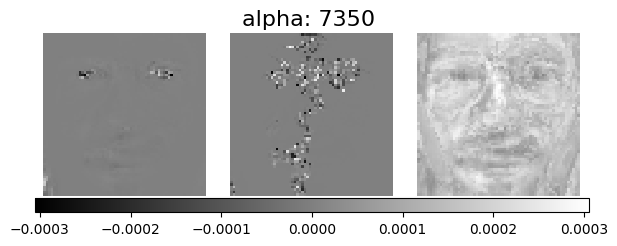

epoch    0 | recon_loss 99473.3906 weight_loss 616567296.0000 codes_loss 0.3546
epoch  200 | recon_loss 32328.0801 weight_loss 29976.7227 codes_loss 314.8896
epoch  400 | recon_loss 11683.9648 weight_loss 20507.9668 codes_loss 1083.0304
epoch  600 | recon_loss 10823.3701 weight_loss 15677.3164 codes_loss 1687.9261
epoch  800 | recon_loss 14140.7324 weight_loss 12975.3047 codes_loss 2142.1794
epoch 1000 | recon_loss 12020.3301 weight_loss 12058.6650 codes_loss 2446.9863
epoch 1200 | recon_loss 13885.0400 weight_loss 12650.9414 codes_loss 2631.9824
epoch 1400 | recon_loss 14404.2578 weight_loss 10037.4629 codes_loss 2710.4941
epoch 1600 | recon_loss 13377.1504 weight_loss 10888.1289 codes_loss 2723.5652
epoch 1800 | recon_loss 13983.9580 weight_loss 10640.8613 codes_loss 2707.3220
epoch 2000 | recon_loss 14841.6494 weight_loss 11328.8721 codes_loss 2650.7646
epoch 2200 | recon_loss 13212.9160 weight_loss 10817.4385 codes_loss 2576.0508
epoch 2400 | recon_loss 14351.7129 weight_loss 11440

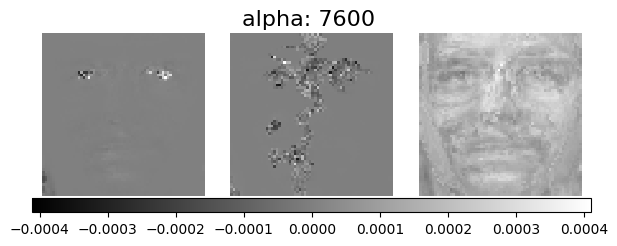

epoch    0 | recon_loss 100683.1328 weight_loss 629018176.0000 codes_loss 0.3516
epoch  200 | recon_loss 19523.8027 weight_loss 27086.5332 codes_loss 547.1214
epoch  400 | recon_loss 10539.3438 weight_loss 17700.4844 codes_loss 1349.9792
epoch  600 | recon_loss 10510.9863 weight_loss 14250.6631 codes_loss 1958.8214
epoch  800 | recon_loss 10304.2461 weight_loss 12679.0361 codes_loss 2379.5984
epoch 1000 | recon_loss 10890.7793 weight_loss 11457.5068 codes_loss 2630.3616
epoch 1200 | recon_loss 12510.9609 weight_loss 10952.2334 codes_loss 2763.7971
epoch 1400 | recon_loss 13403.3154 weight_loss 10239.3516 codes_loss 2798.2444
epoch 1600 | recon_loss 12952.3232 weight_loss 10576.3135 codes_loss 2797.3020
epoch 1800 | recon_loss 12425.9199 weight_loss 10977.8145 codes_loss 2734.2727
epoch 2000 | recon_loss 16806.9648 weight_loss 12197.5254 codes_loss 2664.5686
epoch 2200 | recon_loss 18444.0488 weight_loss 11185.7383 codes_loss 2603.0408
epoch 2400 | recon_loss 13646.5400 weight_loss 1165

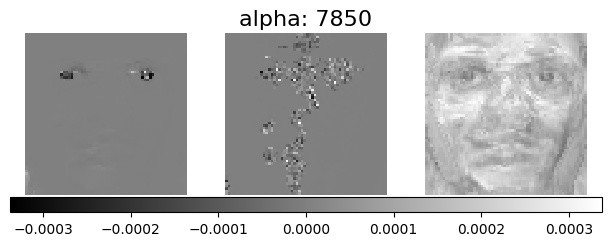

epoch    0 | recon_loss 102616.7422 weight_loss 641469056.0000 codes_loss 0.3448
epoch  200 | recon_loss 27673.0957 weight_loss 29421.5723 codes_loss 386.4601
epoch  400 | recon_loss 11721.8096 weight_loss 19030.1484 codes_loss 1165.1946
epoch  600 | recon_loss 11406.8838 weight_loss 14252.1934 codes_loss 1773.6923
epoch  800 | recon_loss 11880.1025 weight_loss 12160.9326 codes_loss 2221.8003
epoch 1000 | recon_loss 12898.5410 weight_loss 11955.9170 codes_loss 2518.3555
epoch 1200 | recon_loss 12694.3467 weight_loss 11498.6143 codes_loss 2692.6902
epoch 1400 | recon_loss 12776.9111 weight_loss 11379.6475 codes_loss 2760.3806
epoch 1600 | recon_loss 12603.8242 weight_loss 10620.1953 codes_loss 2759.3750
epoch 1800 | recon_loss 13272.8594 weight_loss 10722.3477 codes_loss 2737.5090
epoch 2000 | recon_loss 11995.7773 weight_loss 11698.3418 codes_loss 2684.7156
epoch 2200 | recon_loss 12586.3633 weight_loss 11315.7109 codes_loss 2597.7554
epoch 2400 | recon_loss 20084.2793 weight_loss 1023

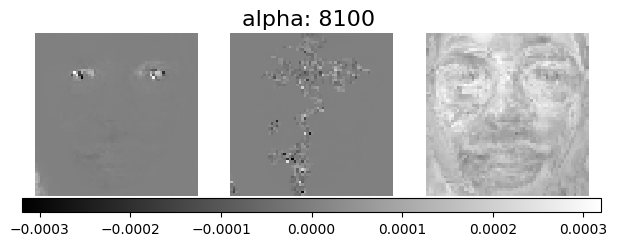

epoch    0 | recon_loss 104360.2031 weight_loss 653919936.0000 codes_loss 0.3537
epoch  200 | recon_loss 40249.0391 weight_loss 29701.6016 codes_loss 248.6062
epoch  400 | recon_loss 12356.8203 weight_loss 21006.2715 codes_loss 1002.0923
epoch  600 | recon_loss 11672.9834 weight_loss 15822.7246 codes_loss 1609.0288
epoch  800 | recon_loss 11502.7100 weight_loss 14304.0371 codes_loss 2077.1824
epoch 1000 | recon_loss 10291.7188 weight_loss 12060.8506 codes_loss 2397.7971
epoch 1200 | recon_loss 11463.4248 weight_loss 11371.4756 codes_loss 2599.6980
epoch 1400 | recon_loss 13766.9863 weight_loss 12138.3467 codes_loss 2713.2847
epoch 1600 | recon_loss 15214.2891 weight_loss 10848.8145 codes_loss 2747.8630
epoch 1800 | recon_loss 16641.8906 weight_loss 9964.3691 codes_loss 2741.2283
epoch 2000 | recon_loss 16702.2812 weight_loss 9790.2285 codes_loss 2679.6943
epoch 2200 | recon_loss 14972.2549 weight_loss 11922.2930 codes_loss 2585.7749
epoch 2400 | recon_loss 13738.4297 weight_loss 11125.

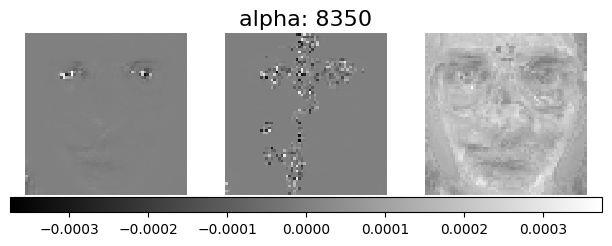

epoch    0 | recon_loss 102216.6562 weight_loss 666370816.0000 codes_loss 0.3458
epoch  200 | recon_loss 20817.2891 weight_loss 27259.3594 codes_loss 525.9444
epoch  400 | recon_loss 10909.8652 weight_loss 18006.8945 codes_loss 1325.1429
epoch  600 | recon_loss 11258.8301 weight_loss 13936.0811 codes_loss 1938.5275
epoch  800 | recon_loss 12004.2236 weight_loss 11816.3779 codes_loss 2371.8948
epoch 1000 | recon_loss 10662.9434 weight_loss 11292.8301 codes_loss 2639.9075
epoch 1200 | recon_loss 14549.6826 weight_loss 10300.6465 codes_loss 2776.3176
epoch 1400 | recon_loss 12240.7939 weight_loss 11224.5293 codes_loss 2839.0056
epoch 1600 | recon_loss 14030.1787 weight_loss 10735.0488 codes_loss 2826.5088
epoch 1800 | recon_loss 12209.5205 weight_loss 11047.8418 codes_loss 2775.3877
epoch 2000 | recon_loss 18114.8008 weight_loss 11688.0430 codes_loss 2708.1125
epoch 2200 | recon_loss 12484.1182 weight_loss 11518.9473 codes_loss 2631.3442
epoch 2400 | recon_loss 15633.9023 weight_loss 1111

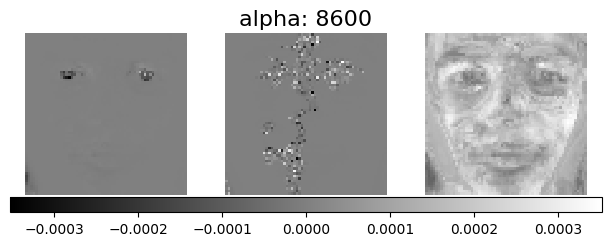

epoch    0 | recon_loss 99458.3203 weight_loss 678821632.0000 codes_loss 0.3449
epoch  200 | recon_loss 24694.1738 weight_loss 28602.8125 codes_loss 439.0435
epoch  400 | recon_loss 10971.5713 weight_loss 18463.0391 codes_loss 1224.9833
epoch  600 | recon_loss 12291.0137 weight_loss 13661.7422 codes_loss 1839.3188
epoch  800 | recon_loss 10286.4922 weight_loss 12494.1484 codes_loss 2284.7004
epoch 1000 | recon_loss 10930.2500 weight_loss 11483.4922 codes_loss 2570.1526
epoch 1200 | recon_loss 14617.3711 weight_loss 10642.0078 codes_loss 2731.8611
epoch 1400 | recon_loss 12024.4844 weight_loss 10423.0293 codes_loss 2807.6536
epoch 1600 | recon_loss 13608.6543 weight_loss 10554.3076 codes_loss 2812.2881
epoch 1800 | recon_loss 12181.8496 weight_loss 10602.4932 codes_loss 2769.6399
epoch 2000 | recon_loss 13238.3057 weight_loss 10494.1387 codes_loss 2707.9526
epoch 2200 | recon_loss 15548.1104 weight_loss 10439.1543 codes_loss 2623.8289
epoch 2400 | recon_loss 14040.2803 weight_loss 11948

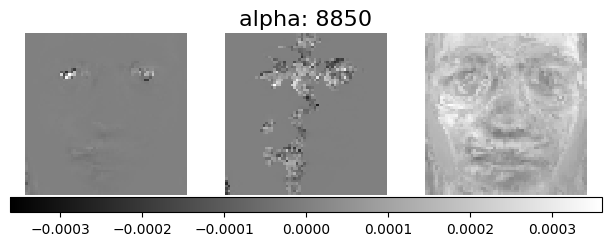

epoch    0 | recon_loss 104417.7188 weight_loss 691272576.0000 codes_loss 0.3492
epoch  200 | recon_loss 37689.9570 weight_loss 29890.2207 codes_loss 272.2051
epoch  400 | recon_loss 12032.9961 weight_loss 20777.3359 codes_loss 1030.1010
epoch  600 | recon_loss 10740.6465 weight_loss 15982.4668 codes_loss 1640.0215
epoch  800 | recon_loss 12589.1689 weight_loss 11896.8184 codes_loss 2105.9695
epoch 1000 | recon_loss 13400.4883 weight_loss 11278.5664 codes_loss 2437.4014
epoch 1200 | recon_loss 14603.9795 weight_loss 11214.4551 codes_loss 2638.9299
epoch 1400 | recon_loss 14089.9150 weight_loss 9781.7441 codes_loss 2730.8835
epoch 1600 | recon_loss 13218.5479 weight_loss 10373.4697 codes_loss 2775.1550
epoch 1800 | recon_loss 14263.0186 weight_loss 10197.3828 codes_loss 2762.9016
epoch 2000 | recon_loss 12429.5986 weight_loss 11057.8242 codes_loss 2709.9404
epoch 2200 | recon_loss 15167.9053 weight_loss 11926.2412 codes_loss 2628.7532
epoch 2400 | recon_loss 20361.5977 weight_loss 10663

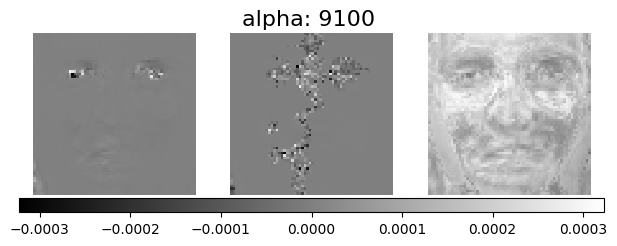

epoch    0 | recon_loss 104618.1406 weight_loss 703723520.0000 codes_loss 0.3493
epoch  200 | recon_loss 25978.5625 weight_loss 29214.8203 codes_loss 401.6321
epoch  400 | recon_loss 11987.6709 weight_loss 18734.2812 codes_loss 1182.0629
epoch  600 | recon_loss 11653.0156 weight_loss 14361.4033 codes_loss 1797.0762
epoch  800 | recon_loss 11462.2158 weight_loss 12554.7305 codes_loss 2255.1353
epoch 1000 | recon_loss 10726.4619 weight_loss 11634.5898 codes_loss 2557.9646
epoch 1200 | recon_loss 12687.7002 weight_loss 11236.8008 codes_loss 2727.1694
epoch 1400 | recon_loss 14772.4346 weight_loss 10296.6943 codes_loss 2812.6858
epoch 1600 | recon_loss 12648.3623 weight_loss 10397.8652 codes_loss 2813.0710
epoch 1800 | recon_loss 13760.0928 weight_loss 9569.6484 codes_loss 2768.3909
epoch 2000 | recon_loss 13766.6367 weight_loss 10793.3291 codes_loss 2705.6477
epoch 2200 | recon_loss 19976.5781 weight_loss 10928.6787 codes_loss 2657.9646
epoch 2400 | recon_loss 15978.6816 weight_loss 11076

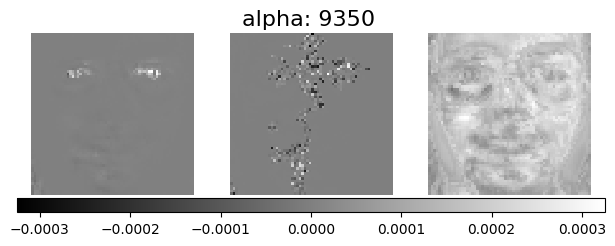

epoch    0 | recon_loss 99486.7500 weight_loss 716174464.0000 codes_loss 0.3503
epoch  200 | recon_loss 34254.1562 weight_loss 29903.1152 codes_loss 309.0177
epoch  400 | recon_loss 12056.5811 weight_loss 20172.3945 codes_loss 1072.8704
epoch  600 | recon_loss 9968.1162 weight_loss 15806.6094 codes_loss 1684.4863
epoch  800 | recon_loss 11372.8291 weight_loss 13022.7617 codes_loss 2153.4329
epoch 1000 | recon_loss 10736.7568 weight_loss 11460.5137 codes_loss 2474.1477
epoch 1200 | recon_loss 13756.1807 weight_loss 11743.5107 codes_loss 2670.7000
epoch 1400 | recon_loss 14014.4219 weight_loss 11237.7412 codes_loss 2777.0664
epoch 1600 | recon_loss 11366.3506 weight_loss 10466.5527 codes_loss 2797.8777
epoch 1800 | recon_loss 11510.9609 weight_loss 11022.1592 codes_loss 2774.5186
epoch 2000 | recon_loss 13685.8164 weight_loss 10811.6523 codes_loss 2714.9380
epoch 2200 | recon_loss 13150.3750 weight_loss 12090.3496 codes_loss 2653.6296
epoch 2400 | recon_loss 14445.6670 weight_loss 11401.

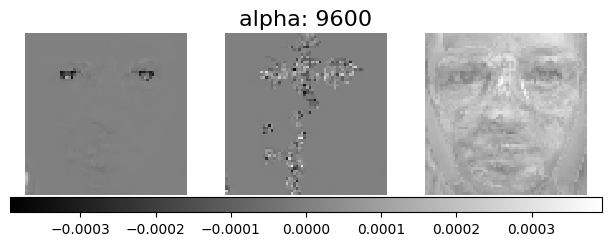

epoch    0 | recon_loss 102102.5781 weight_loss 728625280.0000 codes_loss 0.3515
epoch  200 | recon_loss 21480.1953 weight_loss 27788.8789 codes_loss 502.4116
epoch  400 | recon_loss 10228.5156 weight_loss 18179.1484 codes_loss 1301.0992
epoch  600 | recon_loss 12945.7725 weight_loss 13349.8760 codes_loss 1920.4014
epoch  800 | recon_loss 11408.3789 weight_loss 11947.6035 codes_loss 2359.4521
epoch 1000 | recon_loss 13801.4219 weight_loss 10945.4062 codes_loss 2635.1006
epoch 1200 | recon_loss 14044.4453 weight_loss 10007.7754 codes_loss 2787.2405
epoch 1400 | recon_loss 14085.4902 weight_loss 10032.5000 codes_loss 2853.9856
epoch 1600 | recon_loss 11567.7627 weight_loss 10678.2158 codes_loss 2850.7627
epoch 1800 | recon_loss 14936.0156 weight_loss 11316.3457 codes_loss 2818.5740
epoch 2000 | recon_loss 12189.2051 weight_loss 11566.4102 codes_loss 2752.6924
epoch 2200 | recon_loss 12797.1064 weight_loss 12089.6582 codes_loss 2680.4272
epoch 2400 | recon_loss 17086.4688 weight_loss 1069

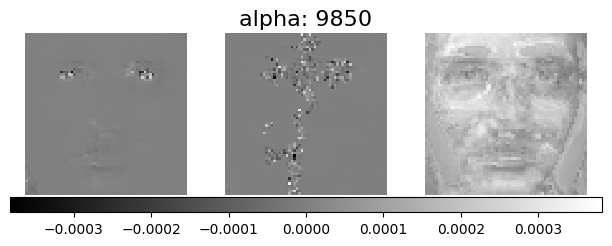

In [18]:
for alpha in range(100,10_000, 250):
    model, codes, components, recon = train_grouping_autoencoder_fixed_sigma(
        faces, n_components, alpha, sigma_x=base_noise_std, sigma_0=1e-4, sigma_s=1, epochs=2500, lr=2e-3
    )
    plot_gallery(f"alpha: {alpha}", components[:n_components])

In [ ]:
# higher alphas seem a lot more predictable it seems, the requirements are much tighter

In [ ]:
show_gram(torch.tensor(components.T))

## Words decomp

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

from time import time

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

n_samples = 2000
n_features = 1000
n_components = 10
n_top_words = 20
batch_size = 128
init = "nndsvda"


def plot_top_words(components_, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


# Load the 20 newsgroups dataset and vectorize it. We use a few heuristics
# to filter out useless terms early on: the posts are stripped of headers,
# footers and quoted replies, and common English words, words occurring in
# only one document or in at least 95% of the documents are removed.

print("Loading dataset...")
t0 = time()
data, _ = fetch_20newsgroups(
    shuffle=True,
    random_state=1,
    remove=("headers", "footers", "quotes"),
    return_X_y=True,
)
data_samples = data[:n_samples]
print("done in %0.3fs." % (time() - t0))

# Use tf-idf features for NMF.
print("Extracting tf-idf features for NMF...")
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
t0 = time()
tfidf = tfidf_vectorizer.fit_transform(data_samples)
print("done in %0.3fs." % (time() - t0))

# Use tf (raw term count) features for LDA.
print("Extracting tf features for LDA...")
tf_vectorizer = CountVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
t0 = time()
tf = tf_vectorizer.fit_transform(data_samples)
print("done in %0.3fs." % (time() - t0))
print()

# Fit the NMF model
print(
    "Fitting the NMF model (Frobenius norm) with tf-idf features, "
    "n_samples=%d and n_features=%d..." % (n_samples, n_features)
)
t0 = time()
nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="frobenius",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=1,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))


tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf.components_, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)"
)

# Fit the NMF model
print(
    "\n" * 2,
    "Fitting the NMF model (generalized Kullback-Leibler "
    "divergence) with tf-idf features, n_samples=%d and n_features=%d..."
    % (n_samples, n_features),
)
t0 = time()
nmf = NMF(
    n_components=n_components,
    random_state=1,
    init=init,
    beta_loss="kullback-leibler",
    solver="mu",
    max_iter=1000,
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=0.5,
).fit(tfidf)
print("done in %0.3fs." % (time() - t0))

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf.components_,
    tfidf_feature_names,
    n_top_words,
    "Topics in NMF model (generalized Kullback-Leibler divergence)",
)

# # Fit the MiniBatchNMF model
# print(
#     "\n" * 2,
#     "Fitting the MiniBatchNMF model (Frobenius norm) with tf-idf "
#     "features, n_samples=%d and n_features=%d, batch_size=%d..."
#     % (n_samples, n_features, batch_size),
# )
# t0 = time()
# mbnmf = MiniBatchNMF(
#     n_components=n_components,
#     random_state=1,
#     batch_size=batch_size,
#     init=init,
#     beta_loss="frobenius",
#     alpha_W=0.00005,
#     alpha_H=0.00005,
#     l1_ratio=0.5,
# ).fit(tfidf)
# print("done in %0.3fs." % (time() - t0))


# tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
# plot_top_words(
#     mbnmf.components_,
#     tfidf_feature_names,
#     n_top_words,
#     "Topics in MiniBatchNMF model (Frobenius norm)",
# )

# # Fit the MiniBatchNMF model
# print(
#     "\n" * 2,
#     "Fitting the MiniBatchNMF model (generalized Kullback-Leibler "
#     "divergence) with tf-idf features, n_samples=%d and n_features=%d, "
#     "batch_size=%d..." % (n_samples, n_features, batch_size),
# )
# t0 = time()
# mbnmf = MiniBatchNMF(
#     n_components=n_components,
#     random_state=1,
#     batch_size=batch_size,
#     init=init,
#     beta_loss="kullback-leibler",
#     alpha_W=0.00005,
#     alpha_H=0.00005,
#     l1_ratio=0.5,
# ).fit(tfidf)
# print("done in %0.3fs." % (time() - t0))

# tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
# plot_top_words(
#     mbnmf.components_,
#     tfidf_feature_names,
#     n_top_words,
#     "Topics in MiniBatchNMF model (generalized Kullback-Leibler divergence)",
# )

# print(
#     "\n" * 2,
#     "Fitting LDA models with tf features, n_samples=%d and n_features=%d..."
#     % (n_samples, n_features),
# )
# lda = LatentDirichletAllocation(
#     n_components=n_components,
#     max_iter=5,
#     learning_method="online",
#     learning_offset=50.0,
#     random_state=0,
# )
# t0 = time()
# lda.fit(tf)
# print("done in %0.3fs." % (time() - t0))

# tf_feature_names = tf_vectorizer.get_feature_names_out()
# plot_top_words(lda.components_, tf_feature_names, n_top_words, "Topics in LDA model")

In [ ]:
us = tfidf.toarray()

In [ ]:
vals = us[us !=0]

print(np.std(us), np.mean(us), np.percentile(us, 75), np.percentile(us, 90))
print(np.std(vals), np.mean(vals), np.percentile(vals, 75), np.percentile(vals, 90))

In [ ]:
# # in some seeds, recon loss does not descend in the beginnign
# # its useful to let it descend a bit in the beginning it seems, a few epochs maybe?
# # is sparse ness a problem with the other dataset?
# # if the data is already sparse, what happens to our weights regularisation?
# all_components, all_recons, all_codes = [], [], []

# code_maker_std = 1
# sigma_0_std = np.std(X) / 2
# sigma_noise = sigma_0_std / 100

# for seed in [10]:
#     print(f"#### seed run: {seed} #########")
#     torch.manual_seed(seed)
#     model, codes, components, recons = train_grouping_autoencoder_fixed_sigma(
#         X, N_COMPS, epochs=5000, sigma_0=sigma_0_std, sigma_s=code_maker_std, sigma_x=sigma_noise, max_alpha=10000, batch_size=256
#     )
#     all_components.append(components)
#     all_recons.append(recons)
#     all_codes.append(codes)

In [ ]:
std_pos, var_noise

In [ ]:
us = tfidf.toarray()
std_us = np.std(us)


std_pos = us[us != 0].std()

var_noise = 0.0001
var_w = 0.001
code_maker_std = 0.001

# the fundamental problem of fighting among each other, w and s, is giving me issues
# i want a uniform prior on s i think, but within a range. i can renormalize s every time maybe?
# the other way is to do coordiante descent. Do w and s in separate steps
torch.manual_seed(1)
model, codes, components, recons = train_grouping_autoencoder_fixed_sigma(
    us, n_components, epochs=2000, sigma_0=var_w, sigma_s=code_maker_std, sigma_x=var_noise, max_alpha=10_000, warmup_epochs=5, w_avg_num_seeds=1
)

In [ ]:
var_noise

In [ ]:
codes[0]

In [ ]:
# with relu, it might just be better to take a distribution which is generally negative
model, codes, components, recons = train_baseline(
    us, n_components, epochs=1000, sigma_x=1, sigma_s=1e-5
)

In [ ]:
codes[0]

In [ ]:
us[0][:10], recons[0][:10]

In [ ]:
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    components,
    tfidf_feature_names,
    n_top_words,
    "Topics in our model",
)

In [ ]:
gram = show_gram(torch.tensor(components.T))
print(gram[5])

In [ ]:
gram